In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# ── Global Style ─────────────────────────────────────────────
PALETTE   = ["#E63946","#F4A261","#2A9D8F","#457B9D","#A8DADC","#E9C46A","#264653","#F77F00"]
CHURN_PAL = {"Existing Customer": "#2A9D8F", "Attrited Customer": "#E63946"}
sns.set_theme(style="whitegrid", font_scale=1.05)

file_path = "BankChurners.csv"
df = pd.read_csv(file_path)
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 10127 rows × 23 columns


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [2]:
# Drop client ID and pre-built Naive Bayes classifier columns (data leakage)
drop_cols = [
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
]
df.drop(columns=drop_cols, inplace=True, errors="ignore")
print(f"After dropping irrelevant columns: {df.shape}")
df.dtypes

After dropping irrelevant columns: (10127, 20)


Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

In [3]:
df.info()
print("\n" + "="*60)
print("Missing values:")
missing = df.isnull().sum()
pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing": missing, "Pct%": pct})
print(missing_df[missing_df["Missing"] > 0] if missing_df["Missing"].sum() > 0 else "No missing values ✓")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nTarget distribution:\n{df['Attrition_Flag'].value_counts()}")
print(f"Churn rate: {(df['Attrition_Flag']=='Attrited Customer').mean()*100:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

# 📊 Statistical Analysis



In [4]:
# ── Descriptive Statistics ────────────────────────────────────
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

desc = df[num_cols].describe().T
desc["variance"]  = df[num_cols].var()
desc["skewness"]  = df[num_cols].skew()
desc["kurtosis"]  = df[num_cols].kurtosis()
desc["IQR"]       = desc["75%"] - desc["25%"]
desc["CV%"]       = (desc["std"] / desc["mean"] * 100).round(2)  # Coefficient of Variation

print("DESCRIPTIVE STATISTICS (with Dispersion & Shape Metrics)")
print("="*100)
display(desc.round(3).style.background_gradient(cmap="YlOrRd", subset=["skewness","kurtosis"])
        .format("{:.3f}"))

DESCRIPTIVE STATISTICS (with Dispersion & Shape Metrics)


,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,IQR,CV%
Customer_Age,10127.000,46.326,8.017,26.000,41.000,46.000,52.000,73.000,64.269,-0.034,-0.289,11.000,17.310
Dependent_count,10127.000,2.346,1.299,0.000,1.000,2.000,3.000,5.000,1.687,-0.021,-0.683,2.000,55.360
Months_on_book,10127.000,35.928,7.986,13.000,31.000,36.000,40.000,56.000,63.783,-0.107,0.400,9.000,22.230
Total_Relationship_Count,10127.000,3.813,1.554,1.000,3.000,4.000,5.000,6.000,2.416,-0.162,-1.006,2.000,40.770
Months_Inactive_12_mon,10127.000,2.341,1.011,0.000,2.000,2.000,3.000,6.000,1.021,0.633,1.099,1.000,43.170
Contacts_Count_12_mon,10127.000,2.455,1.106,0.000,2.000,2.000,3.000,6.000,1.224,0.011,0.001,1.000,45.050
Credit_Limit,10127.000,8631.954,9088.777,1438.300,2555.000,4549.000,11067.500,34516.000,82605860.998,1.667,1.809,8512.500,105.290
Total_Revolving_Bal,10127.000,1162.814,814.987,0.000,359.000,1276.000,1784.000,2517.000,664204.357,-0.149,-1.146,1425.000,70.090
Avg_Open_To_Buy,10127.000,7469.140,9090.685,3.000,1324.500,3474.000,9859.000,34516.000,82640559.654,1.662,1.799,8534.500,121.710
Total_Amt_Chng_Q4_Q1,10127.000,0.760,0.219,0.000,0.631,0.736,0.859,3.397,0.048,1.732,9.994,0.228,28.850


In [5]:
# ── Normality Tests (D'Agostino-Pearson) ─────────────────────
# Rationale: Determines whether parametric (t-test) or non-parametric
# (Mann-Whitney U) tests are appropriate for each feature.
from scipy.stats import normaltest, shapiro

normality_results = []
for col in num_cols:
    stat, p = normaltest(df[col].dropna())
    normality_results.append({
        "Feature": col,
        "D'Agostino Stat": round(stat, 3),
        "p-value": f"{p:.2e}",
        "Normal?": "YES" if p > 0.05 else "NO"
    })

norm_df = pd.DataFrame(normality_results)
print("D'AGOSTINO-PEARSON NORMALITY TEST")
print("H₀: Data comes from a normal distribution")
print("="*70)
print(norm_df.to_string(index=False))
print(f"\n→ {(norm_df['Normal?']=='NO').sum()}/{len(norm_df)} features reject normality.")
print("→ Non-parametric tests (Mann-Whitney U) will be used for group comparisons.")

D'AGOSTINO-PEARSON NORMALITY TEST
H₀: Data comes from a normal distribution
                 Feature  D'Agostino Stat   p-value Normal?
            Customer_Age           50.083  1.33e-11      NO
         Dependent_count          492.781 9.86e-108      NO
          Months_on_book           66.925  2.93e-15      NO
Total_Relationship_Count         2434.459  0.00e+00      NO
  Months_Inactive_12_mon          797.459 6.82e-174      NO
   Contacts_Count_12_mon            0.206  9.02e-01     YES
            Credit_Limit         2830.071  0.00e+00      NO
     Total_Revolving_Bal         5712.190  0.00e+00      NO
         Avg_Open_To_Buy         2818.335  0.00e+00      NO
    Total_Amt_Chng_Q4_Q1         4293.592  0.00e+00      NO
         Total_Trans_Amt         3969.255  0.00e+00      NO
          Total_Trans_Ct          125.813  4.79e-28      NO
     Total_Ct_Chng_Q4_Q1         5324.445  0.00e+00      NO
   Avg_Utilization_Ratio         1547.449  0.00e+00      NO

→ 13/14 features reject

In [6]:
# ── Mann-Whitney U Tests (Numerical Features vs Churn) ───────
# Rationale: Since features are non-normal, we use Mann-Whitney U
# (non-parametric) to test if distributions differ between churned/existing.
from scipy.stats import mannwhitneyu

existing = df[df["Attrition_Flag"] == "Existing Customer"]
attrited = df[df["Attrition_Flag"] == "Attrited Customer"]

mwu_results = []
for col in num_cols:
    stat, p = mannwhitneyu(existing[col].dropna(), attrited[col].dropna(), alternative="two-sided")
    # Rank-biserial correlation as effect size: r = 1 - (2U)/(n1*n2)
    n1, n2 = len(existing), len(attrited)
    r_effect = 1 - (2 * stat) / (n1 * n2)
    effect_label = "Large" if abs(r_effect) >= 0.5 else ("Medium" if abs(r_effect) >= 0.3 else "Small")
    mwu_results.append({
        "Feature": col,
        "U-Statistic": f"{stat:.0f}",
        "p-value": f"{p:.2e}",
        "Effect Size (r)": round(r_effect, 4),
        "Effect": effect_label,
        "Significant": "YES ✅" if p < 0.05 else "NO ❌"
    })

mwu_df = pd.DataFrame(mwu_results).sort_values("Effect Size (r)", key=abs, ascending=False)
print("MANN-WHITNEY U TESTS (Numerical Features vs Attrition)")
print("H₀: No difference in distributions between Existing and Attrited")
print("="*90)
print(mwu_df.to_string(index=False))
print(f"\n→ {(mwu_df['Significant']=='YES ✅').sum()}/{len(mwu_df)} features show significant differences.")

MANN-WHITNEY U TESTS (Numerical Features vs Attrition)
H₀: No difference in distributions between Existing and Attrited
                 Feature U-Statistic   p-value  Effect Size (r) Effect Significant
          Total_Trans_Ct    11003326  0.00e+00          -0.5913  Large       YES ✅
     Total_Ct_Chng_Q4_Q1    10307283 1.91e-216          -0.4906 Medium       YES ✅
     Total_Revolving_Bal     9510716 1.92e-129          -0.3754 Medium       YES ✅
   Avg_Utilization_Ratio     9509094 2.87e-129          -0.3752 Medium       YES ✅
         Total_Trans_Amt     9347620 2.72e-112          -0.3518 Medium       YES ✅
   Contacts_Count_12_mon     4938650  1.11e-80           0.2858  Small       YES ✅
  Months_Inactive_12_mon     5142082  5.42e-67           0.2564  Small       YES ✅
Total_Relationship_Count     8514158  2.91e-51          -0.2313  Small       YES ✅
    Total_Amt_Chng_Q4_Q1     8023238  1.06e-24          -0.1603  Small       YES ✅
            Credit_Limit     7468152  3.01e-07    

In [7]:
# ── Chi-Square Tests + Cramér's V (Categorical Features vs Churn) ──
# Rationale: Chi-square tests independence; Cramér's V quantifies
# the strength of association (effect size) for categorical features.
from scipy.stats import chi2_contingency

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
if "Attrition_Flag" in cat_cols:
    cat_cols.remove("Attrition_Flag")

chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df["Attrition_Flag"])
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    effect_label = "Strong" if cramers_v >= 0.25 else ("Moderate" if cramers_v >= 0.15 else "Weak")
    chi2_results.append({
        "Feature": col, "Chi²": round(chi2, 3), "p-value": f"{p:.2e}",
        "DoF": dof, "Cramér's V": round(cramers_v, 4),
        "Strength": effect_label, "Significant": "YES ✅" if p < 0.05 else "NO ❌"
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("Cramér's V", ascending=False)
print("CHI-SQUARE TESTS + CRAMÉR'S V (Categorical Features vs Attrition)")
print("H₀: Feature and Attrition are independent")
print("="*90)
print(chi2_df.to_string(index=False))

CHI-SQUARE TESTS + CRAMÉR'S V (Categorical Features vs Attrition)
H₀: Feature and Attrition are independent
        Feature   Chi²  p-value  DoF  Cramér's V Strength Significant
         Gender 13.866 1.96e-04    1      0.0370     Weak       YES ✅
Income_Category 12.832 2.50e-02    5      0.0356     Weak       YES ✅
Education_Level 12.511 5.15e-02    6      0.0351     Weak        NO ❌
 Marital_Status  6.056 1.09e-01    3      0.0245     Weak        NO ❌
  Card_Category  2.234 5.25e-01    3      0.0149     Weak        NO ❌


POINT-BISERIAL CORRELATION (Numerical Features vs Churn)
                 Feature  Correlation   p-value           Direction
          Total_Trans_Ct      -0.3714  0.00e+00  ↓ Lower in Churned
     Total_Ct_Chng_Q4_Q1      -0.2901 1.65e-195  ↓ Lower in Churned
     Total_Revolving_Bal      -0.2631 6.63e-160  ↓ Lower in Churned
   Contacts_Count_12_mon       0.2045  4.70e-96 ↑ Higher in Churned
   Avg_Utilization_Ratio      -0.1784  3.36e-73  ↓ Lower in Churned
         Total_Trans_Amt      -0.1686  1.86e-65  ↓ Lower in Churned
  Months_Inactive_12_mon       0.1524  1.03e-53 ↑ Higher in Churned
Total_Relationship_Count      -0.1500  4.83e-52  ↓ Lower in Churned
    Total_Amt_Chng_Q4_Q1      -0.1311  4.84e-40  ↓ Lower in Churned
            Credit_Limit      -0.0239  1.63e-02  ↓ Lower in Churned
         Dependent_count       0.0190  5.60e-02 ↑ Higher in Churned
            Customer_Age       0.0182  6.70e-02 ↑ Higher in Churned
          Months_on_book       0.0137  1.68e-01 ↑ Higher in

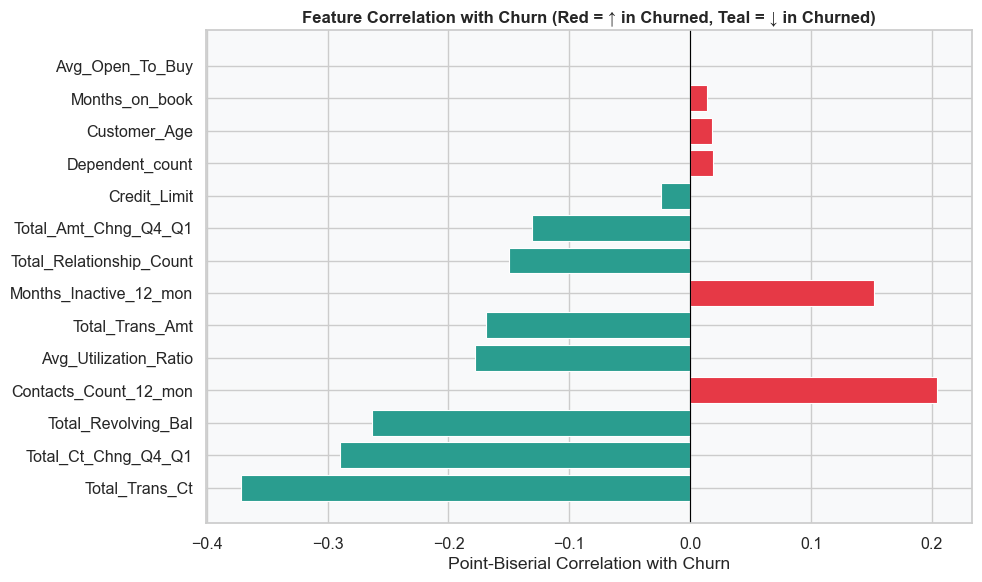

In [8]:
# ── Point-Biserial Correlation (Numerical vs Binary Target) ──
# Rationale: Measures linear association between each numerical
# feature and the binary churn target. Helps identify which features
# have the strongest linear predictive signal.
from scipy.stats import pointbiserialr

churn_binary = (df["Attrition_Flag"] == "Attrited Customer").astype(int)

pb_results = []
for col in num_cols:
    corr, p = pointbiserialr(churn_binary, df[col])
    pb_results.append({
        "Feature": col,
        "Correlation": round(corr, 4),
        "Abs Corr": round(abs(corr), 4),
        "p-value": f"{p:.2e}",
        "Direction": "↑ Higher in Churned" if corr > 0 else "↓ Lower in Churned"
    })

pb_df = pd.DataFrame(pb_results).sort_values("Abs Corr", ascending=False)
print("POINT-BISERIAL CORRELATION (Numerical Features vs Churn)")
print("="*85)
print(pb_df.drop(columns="Abs Corr").to_string(index=False))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E63946" if c > 0 else "#2A9D8F" for c in pb_df["Correlation"]]
ax.barh(pb_df["Feature"], pb_df["Correlation"], color=colors, edgecolor="white", linewidth=0.8)
ax.set_xlabel("Point-Biserial Correlation with Churn")
ax.set_title("Feature Correlation with Churn (Red = ↑ in Churned, Teal = ↓ in Churned)",
             fontsize=12, fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_facecolor("#F8F9FA")
plt.tight_layout()
plt.show()

In [9]:
# ── Variance Inflation Factor (Multicollinearity Check) ──────
# Rationale: High VIF (>10) indicates severe multicollinearity,
# which inflates coefficient variance in linear models and can
# cause instability. Guides feature selection/engineering.
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[num_cols].dropna()
# Standardize first for numerical stability
from sklearn.preprocessing import StandardScaler
X_vif_scaled = pd.DataFrame(StandardScaler().fit_transform(X_vif), columns=X_vif.columns)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif_scaled.values, i) for i in range(X_vif_scaled.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data["Concern"] = vif_data["VIF"].apply(
    lambda v: "🔴 Severe" if v > 10 else ("🟡 Moderate" if v > 5 else "🟢 OK"))

print("VARIANCE INFLATION FACTOR (Multicollinearity)")
print("VIF > 10 = severe multicollinearity, VIF > 5 = moderate concern")
print("="*60)
print(vif_data.to_string(index=False))
print(f"\n→ {(vif_data['VIF'] > 10).sum()} features with severe multicollinearity")
print("Note: Credit_Limit & Avg_Open_To_Buy are linearly related")
print("      (Avg_Open_To_Buy = Credit_Limit - Total_Revolving_Bal)")
print("→ This guides our feature engineering: create ratios instead of raw values.")

VARIANCE INFLATION FACTOR (Multicollinearity)
VIF > 10 = severe multicollinearity, VIF > 5 = moderate concern
                 Feature      VIF  Concern
            Credit_Limit      inf 🔴 Severe
     Total_Revolving_Bal      inf 🔴 Severe
         Avg_Open_To_Buy      inf 🔴 Severe
         Total_Trans_Amt 3.263320     🟢 OK
          Total_Trans_Ct 3.024481     🟢 OK
   Avg_Utilization_Ratio 2.900014     🟢 OK
            Customer_Age 2.675596     🟢 OK
          Months_on_book 2.658376     🟢 OK
     Total_Ct_Chng_Q4_Q1 1.208277     🟢 OK
    Total_Amt_Chng_Q4_Q1 1.192111     🟢 OK
Total_Relationship_Count 1.155622     🟢 OK
   Contacts_Count_12_mon 1.037201     🟢 OK
         Dependent_count 1.028368     🟢 OK
  Months_Inactive_12_mon 1.011255     🟢 OK

→ 3 features with severe multicollinearity
Note: Credit_Limit & Avg_Open_To_Buy are linearly related
      (Avg_Open_To_Buy = Credit_Limit - Total_Revolving_Bal)
→ This guides our feature engineering: create ratios instead of raw values.


# 🔍 Exploratory Data Analysis (EDA)

Visual exploration of distributions, relationships, and patterns in the data.

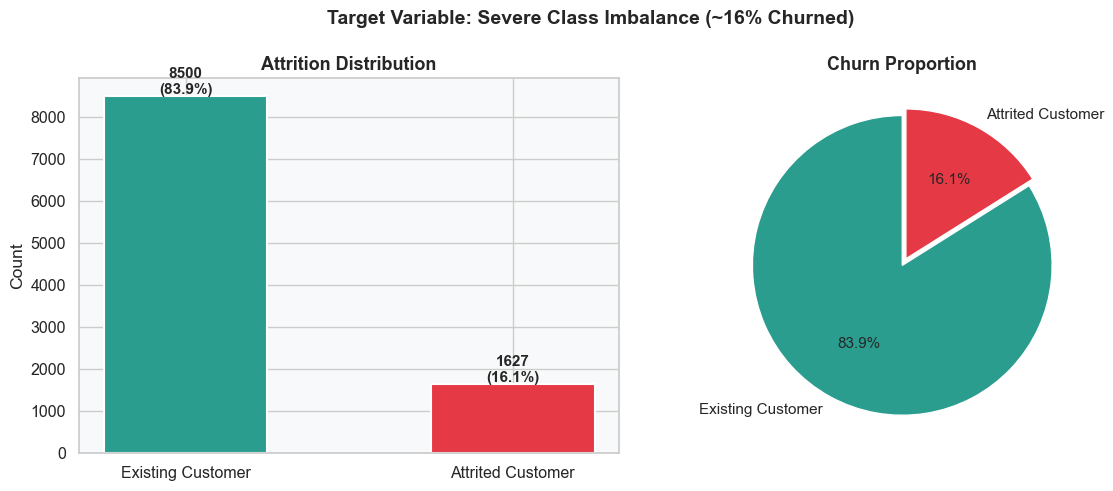

In [10]:
# ── Target Variable Distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df["Attrition_Flag"].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[CHURN_PAL[k] for k in counts.index],
                   edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", fontweight="bold", fontsize=11)
axes[0].set_title("Attrition Distribution", fontsize=13, fontweight="bold")
axes[0].set_facecolor("#F8F9FA")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[CHURN_PAL[k] for k in counts.index],
            startangle=90, explode=(0, 0.05), textprops={"fontsize": 11})
axes[1].set_title("Churn Proportion", fontsize=13, fontweight="bold")

plt.suptitle("Target Variable: Severe Class Imbalance (~16% Churned)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

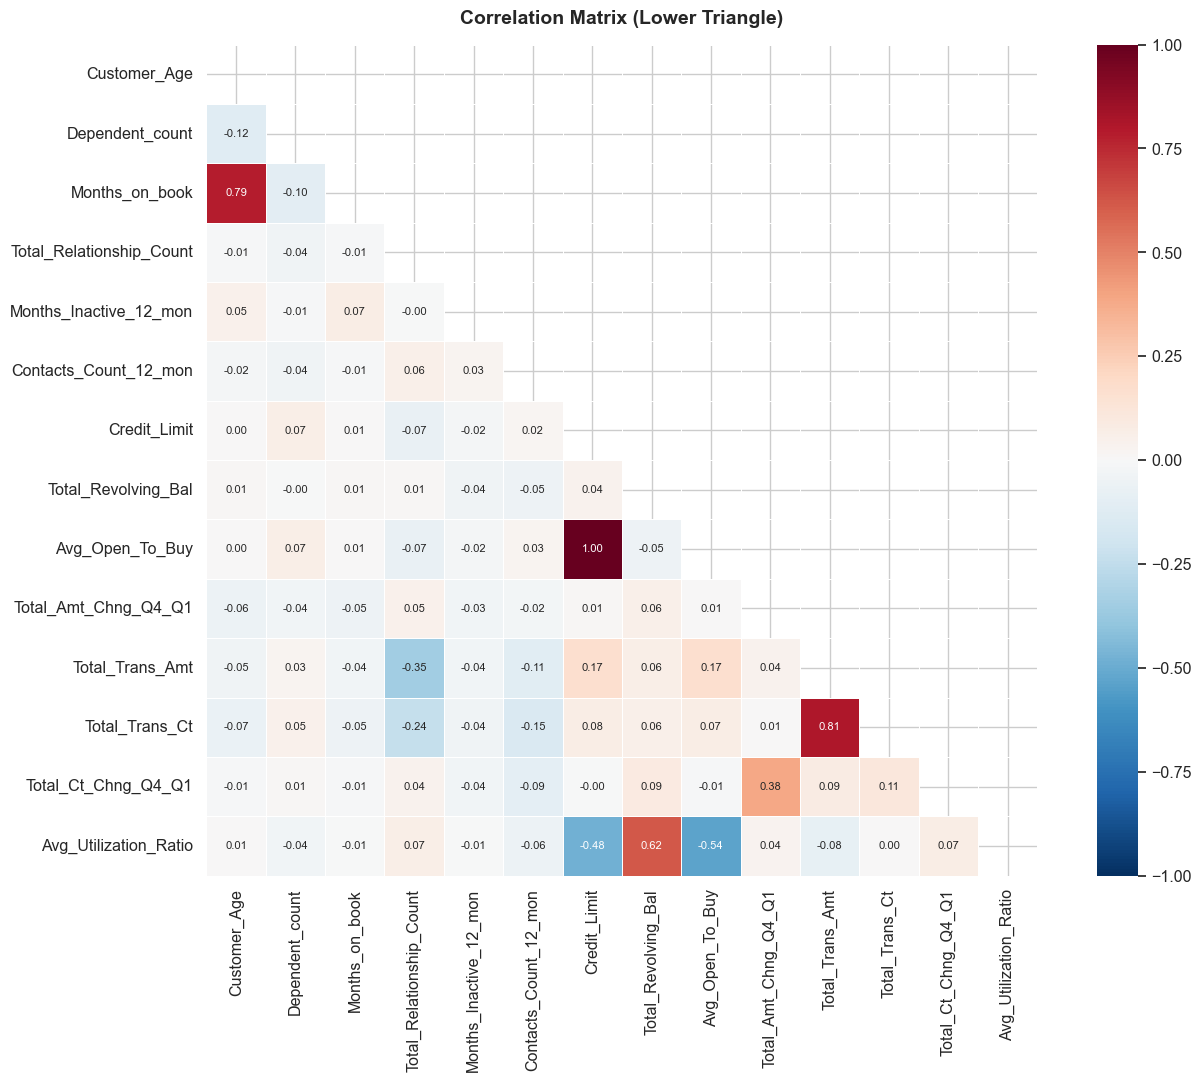

Highly Correlated Pairs (|r| > 0.7):
  Credit_Limit ↔ Avg_Open_To_Buy: r = 0.996
  Total_Trans_Amt ↔ Total_Trans_Ct: r = 0.807
  Customer_Age ↔ Months_on_book: r = 0.789


In [11]:
# ── Correlation Heatmap ──────────────────────────────────────
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Matrix (Lower Triangle)", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Highlight highly correlated pairs (|r| > 0.7)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))
if high_corr:
    print("Highly Correlated Pairs (|r| > 0.7):")
    for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {a} ↔ {b}: r = {r}")

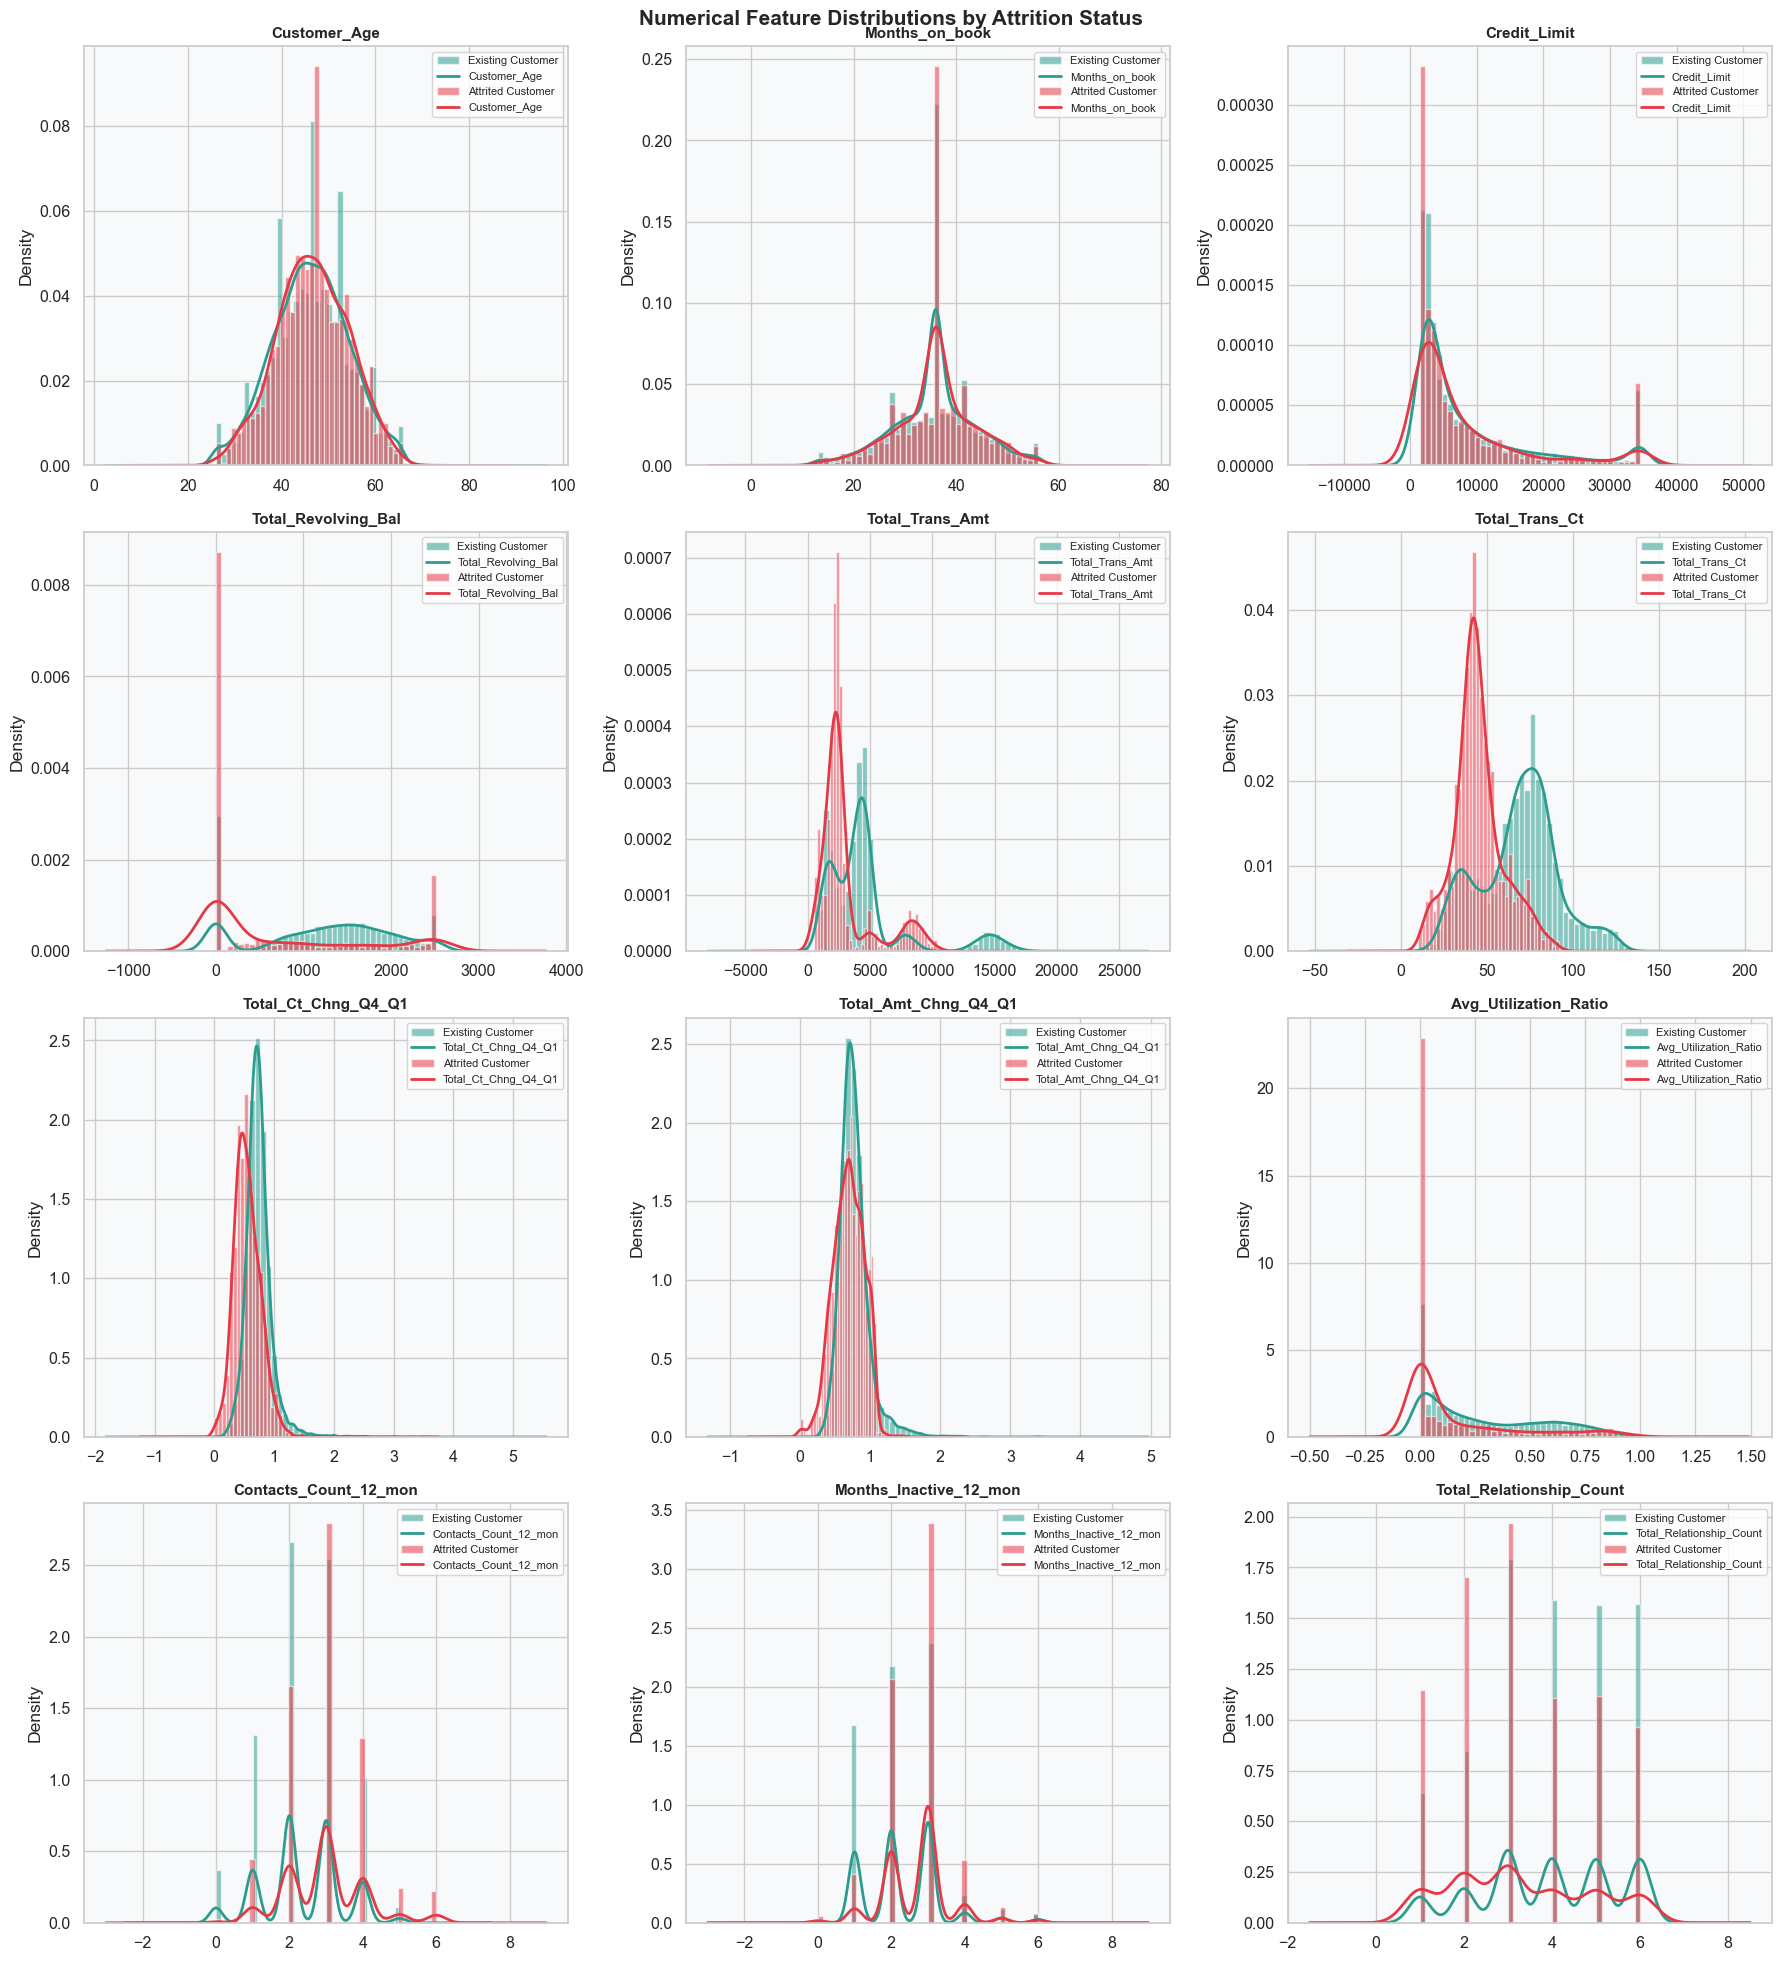

In [12]:
# ── Numerical Feature Distributions by Churn ─────────────────
plot_cols = ["Customer_Age","Months_on_book","Credit_Limit","Total_Revolving_Bal",
             "Total_Trans_Amt","Total_Trans_Ct","Total_Ct_Chng_Q4_Q1",
             "Total_Amt_Chng_Q4_Q1","Avg_Utilization_Ratio","Contacts_Count_12_mon",
             "Months_Inactive_12_mon","Total_Relationship_Count"]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.ravel()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    for label, color in CHURN_PAL.items():
        subset = df[df["Attrition_Flag"] == label][col]
        ax.hist(subset, bins=40, alpha=0.55, color=color, label=label, density=True, edgecolor="white")
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_facecolor("#F8F9FA")
    ax.legend(fontsize=8)

plt.suptitle("Numerical Feature Distributions by Attrition Status",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

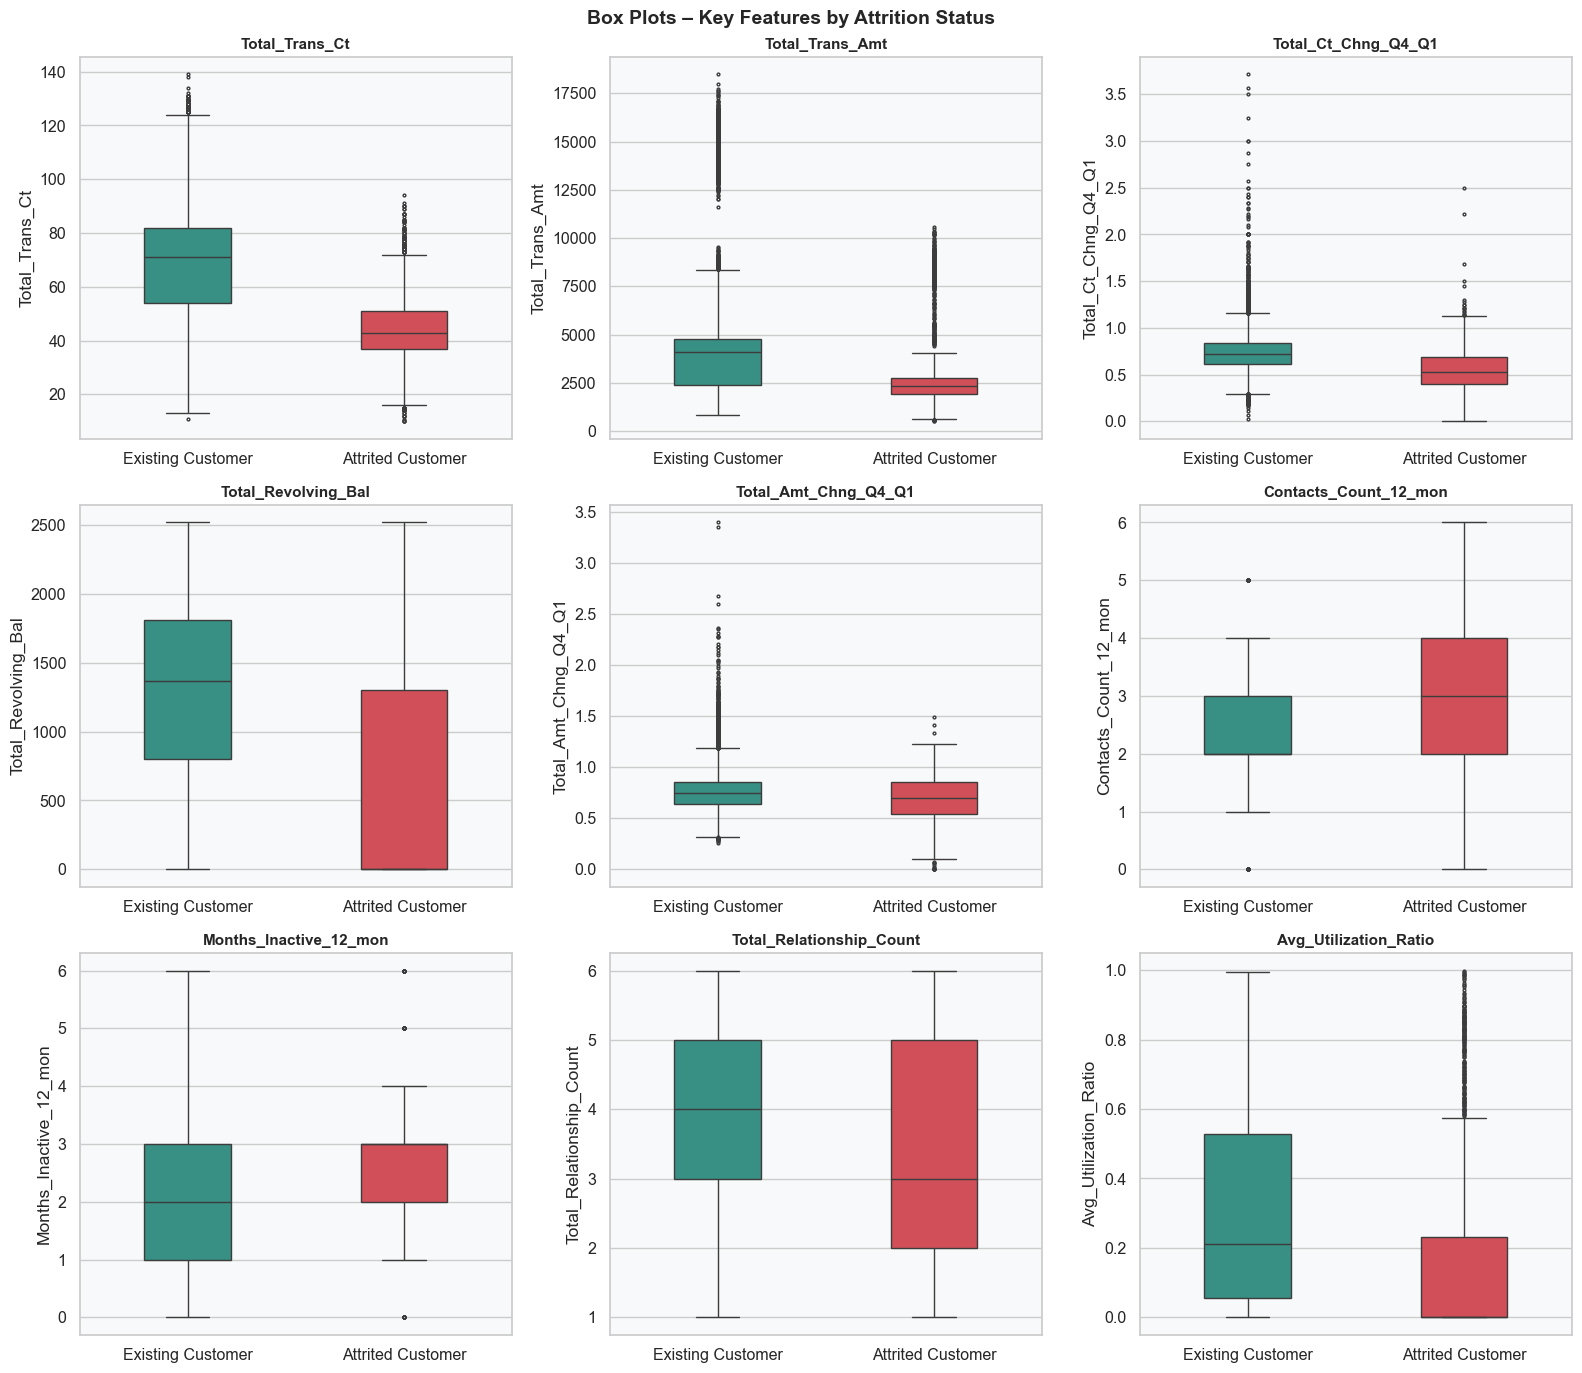

In [13]:
# ── Box Plots by Churn (Key Features) ────────────────────────
# Selecting features with highest point-biserial correlation
key_features = ["Total_Trans_Ct","Total_Trans_Amt","Total_Ct_Chng_Q4_Q1",
                "Total_Revolving_Bal","Total_Amt_Chng_Q4_Q1","Contacts_Count_12_mon",
                "Months_Inactive_12_mon","Total_Relationship_Count","Avg_Utilization_Ratio"]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x="Attrition_Flag", y=col, ax=axes[i],
                palette=CHURN_PAL, width=0.4, fliersize=2)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_facecolor("#F8F9FA")

plt.suptitle("Box Plots – Key Features by Attrition Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

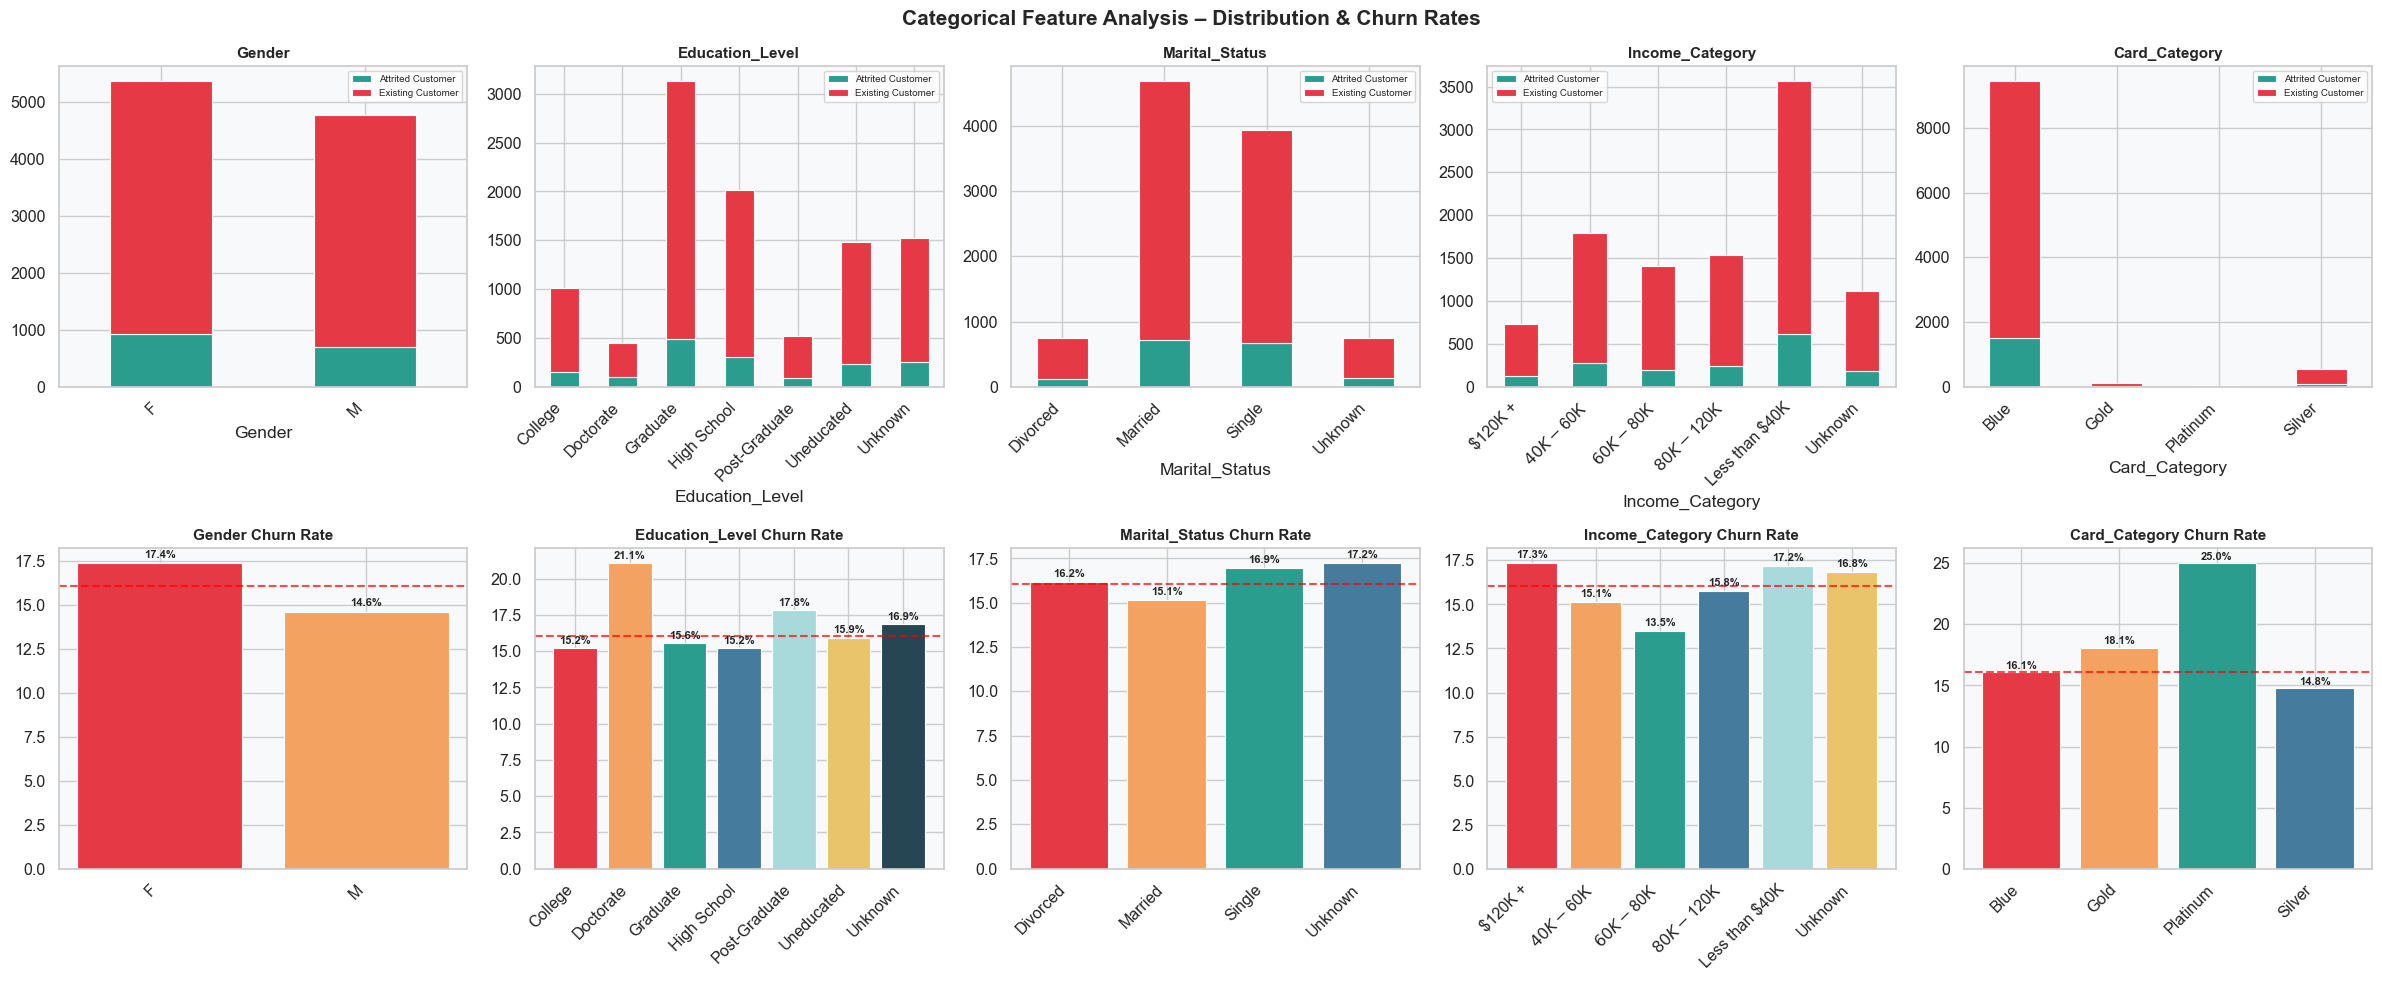

In [14]:
# ── Categorical Feature Analysis ─────────────────────────────
cat_eda_cols = ["Gender","Education_Level","Marital_Status","Income_Category","Card_Category"]

fig, axes = plt.subplots(2, 5, figsize=(24, 10))

for i, col in enumerate(cat_eda_cols):
    # Top row: count plots
    ct = pd.crosstab(df[col], df["Attrition_Flag"])
    ct.plot(kind="bar", stacked=True, ax=axes[0, i],
            color=[CHURN_PAL["Existing Customer"], CHURN_PAL["Attrited Customer"]],
            edgecolor="white", linewidth=0.8)
    axes[0, i].set_title(col, fontsize=11, fontweight="bold")
    axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=45, ha="right")
    axes[0, i].legend(fontsize=7)
    axes[0, i].set_facecolor("#F8F9FA")

    # Bottom row: churn rate per category
    churn_rate = df.groupby(col)["Attrition_Flag"].apply(
        lambda x: (x == "Attrited Customer").mean() * 100)
    bars = axes[1, i].bar(churn_rate.index, churn_rate.values,
                          color=PALETTE[:len(churn_rate)], edgecolor="white", linewidth=0.8)
    for bar in bars:
        axes[1, i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f"{bar.get_height():.1f}%", ha="center", fontsize=8, fontweight="bold")
    axes[1, i].set_title(f"{col} Churn Rate", fontsize=11, fontweight="bold")
    axes[1, i].set_xticklabels(churn_rate.index, rotation=45, ha="right")
    axes[1, i].axhline(y=df["Attrition_Flag"].apply(lambda x: x=="Attrited Customer").mean()*100,
                       color="red", linestyle="--", alpha=0.7, label="Overall Rate")
    axes[1, i].set_facecolor("#F8F9FA")

plt.suptitle("Categorical Feature Analysis – Distribution & Churn Rates",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# ── Outlier Detection (IQR Method) ───────────────────────────
# Rationale: Identifying outliers helps understand data quality
# and whether extreme values could bias models.

outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    outlier_summary.append({
        "Feature": col, "Q1": round(Q1, 2), "Q3": round(Q3, 2),
        "IQR": round(IQR, 2), "Lower Fence": round(lower, 2),
        "Upper Fence": round(upper, 2), "Outliers": n_outliers,
        "Outlier %": round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outlier %", ascending=False)
print("OUTLIER DETECTION (IQR Method: 1.5 × IQR)")
print("="*95)
print(outlier_df.to_string(index=False))
print(f"\n→ Note: We retain outliers as they represent genuine customer behavior extremes.")
print("→ Tree-based models (RF, XGBoost, LightGBM) are robust to outliers.")

OUTLIER DETECTION (IQR Method: 1.5 × IQR)
                 Feature      Q1       Q3     IQR  Lower Fence  Upper Fence  Outliers  Outlier %
            Credit_Limit 2555.00 11067.50 8512.50    -10213.75     23836.25       984       9.72
         Avg_Open_To_Buy 1324.50  9859.00 8534.50    -11477.25     22660.75       963       9.51
         Total_Trans_Amt 2155.50  4741.00 2585.50     -1722.75      8619.25       896       8.85
   Contacts_Count_12_mon    2.00     3.00    1.00         0.50         4.50       629       6.21
    Total_Amt_Chng_Q4_Q1    0.63     0.86    0.23         0.29         1.20       396       3.91
     Total_Ct_Chng_Q4_Q1    0.58     0.82    0.24         0.23         1.17       394       3.89
          Months_on_book   31.00    40.00    9.00        17.50        53.50       386       3.81
  Months_Inactive_12_mon    2.00     3.00    1.00         0.50         4.50       331       3.27
            Customer_Age   41.00    52.00   11.00        24.50        68.50         2

In [16]:
# ── Interactive Exploration (Plotly) ──────────────────────────
fig = px.scatter(df, x="Total_Trans_Ct", y="Total_Trans_Amt",
                 color="Attrition_Flag", opacity=0.5,
                 color_discrete_map=CHURN_PAL,
                 title="Transaction Count vs Amount by Attrition Status",
                 hover_data=["Credit_Limit","Avg_Utilization_Ratio"])
fig.update_layout(template="plotly_white", width=900, height=550)
fig.show()

fig2 = px.box(df, x="Attrition_Flag", y="Total_Trans_Amt", facet_col="Card_Category",
              color="Attrition_Flag", color_discrete_map=CHURN_PAL,
              title="Transaction Amount by Card Category & Attrition")
fig2.update_layout(template="plotly_white", width=1000, height=450, showlegend=False)
fig2.show()

# ⚙️ Feature Engineering



In [17]:
print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# ── 1. Transaction Behavior (Strongest predictors from statistical tests) ──
# Total_Trans_Ct had the highest point-biserial correlation with churn
df["AvgTransactionValue"] = df["Total_Trans_Amt"] / (df["Total_Trans_Ct"] + 1)
# Ratio of change captures momentum in transaction behavior
df["TransactionChangeRatio"] = df["Total_Amt_Chng_Q4_Q1"] / (df["Total_Ct_Chng_Q4_Q1"] + 1e-3)

# ── 2. Utilization & Credit (VIF showed Credit_Limit ↔ Avg_Open_To_Buy multicollinearity) ──
# Using ratio instead of raw values reduces multicollinearity
df["CreditUtilization"] = df["Total_Revolving_Bal"] / (df["Credit_Limit"] + 1)
df["BalanceToLimit"] = df["Total_Revolving_Bal"] / (df["Avg_Open_To_Buy"] + 1)

# ── 3. Engagement Score (Combines relationship breadth × transaction frequency) ──
# Both Total_Relationship_Count and Total_Trans_Ct showed significant group differences
df["EngagementScore"] = df["Total_Relationship_Count"] * df["Total_Trans_Ct"]
df["ProductUsageIntensity"] = df["Total_Trans_Ct"] / (df["Total_Relationship_Count"] + 1)

# ── 4. Inactivity Risk (Months_Inactive × Contacts showed strong churn signal) ──
# Interaction: customers who are inactive AND not contacting the bank → high risk
df["InactivityRisk"] = df["Months_Inactive_12_mon"] * (df["Contacts_Count_12_mon"] + 1)
df["ContactsPerInactiveMonth"] = df["Contacts_Count_12_mon"] / (df["Months_Inactive_12_mon"] + 1)

# ── 5. Age & Tenure Groups (Binning for interpretability) ──
df["AgeGroup"] = pd.cut(df["Customer_Age"],
                        bins=[0, 30, 40, 50, 60, 100],
                        labels=["<30","30-40","40-50","50-60","60+"])
df["TenureGroup"] = pd.cut(df["Months_on_book"],
                           bins=[0, 24, 36, 48, 60, 100],
                           labels=["<2yr","2-3yr","3-4yr","4-5yr","5+yr"])

# ── 6. Log transforms for highly skewed features ──
for col in ["Credit_Limit", "Total_Trans_Amt", "Avg_Open_To_Buy"]:
    df[f"Log_{col}"] = np.log1p(df[col])

new_features = ["AvgTransactionValue","TransactionChangeRatio","CreditUtilization",
                "BalanceToLimit","EngagementScore","ProductUsageIntensity",
                "InactivityRisk","ContactsPerInactiveMonth",
                "AgeGroup","TenureGroup","Log_Credit_Limit","Log_Total_Trans_Amt","Log_Avg_Open_To_Buy"]
print(f"Created {len(new_features)} new features:")
for f in new_features:
    print(f"  • {f}")
print(f"\nNew shape: {df.shape}")

FEATURE ENGINEERING
Created 13 new features:
  • AvgTransactionValue
  • TransactionChangeRatio
  • CreditUtilization
  • BalanceToLimit
  • EngagementScore
  • ProductUsageIntensity
  • InactivityRisk
  • ContactsPerInactiveMonth
  • AgeGroup
  • TenureGroup
  • Log_Credit_Limit
  • Log_Total_Trans_Amt
  • Log_Avg_Open_To_Buy

New shape: (10127, 33)


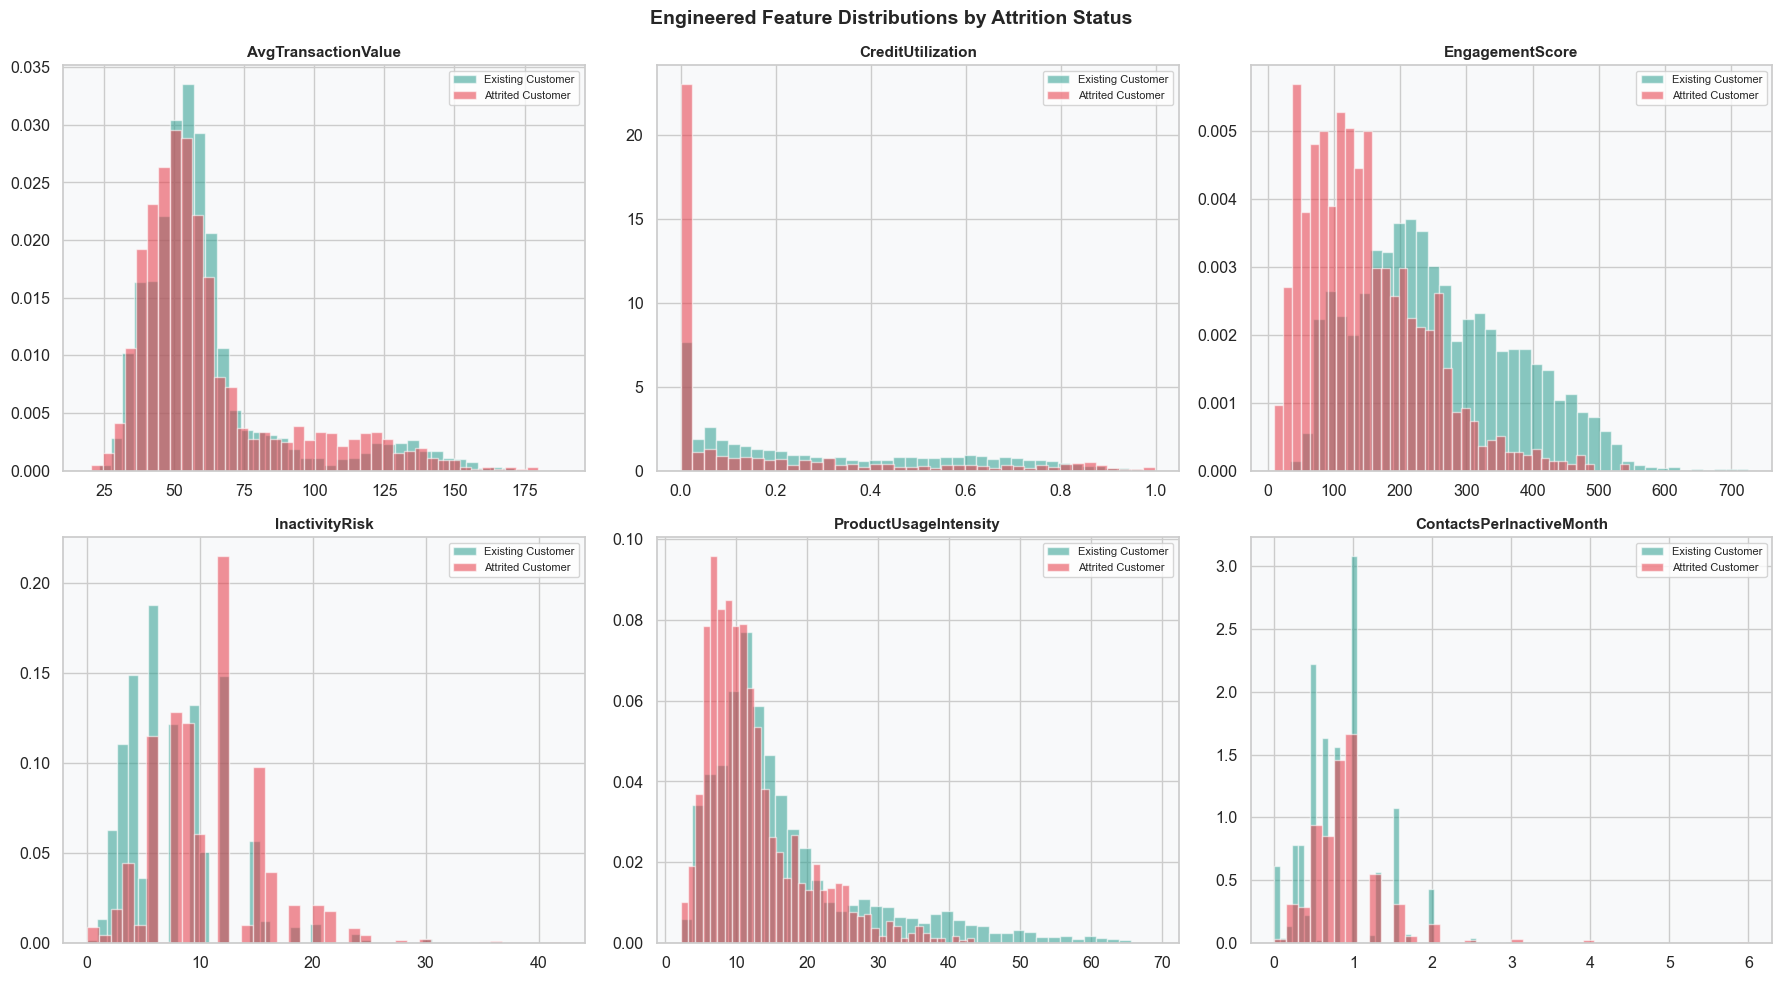

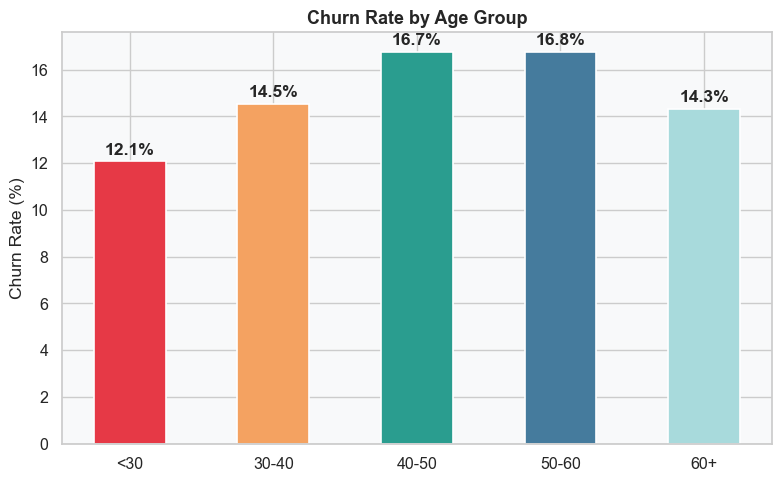

In [18]:
# ── Visualize Engineered Features by Churn ────────────────────
eng_plot_cols = ["AvgTransactionValue","CreditUtilization","EngagementScore",
                 "InactivityRisk","ProductUsageIntensity","ContactsPerInactiveMonth"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, col in enumerate(eng_plot_cols):
    for label, color in CHURN_PAL.items():
        subset = df[df["Attrition_Flag"] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.55, color=color, label=label, density=True, edgecolor="white")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_facecolor("#F8F9FA")
    axes[i].legend(fontsize=8)

plt.suptitle("Engineered Feature Distributions by Attrition Status",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Churn rate by age group
churn_by_age = df.groupby("AgeGroup", observed=True)["Attrition_Flag"].apply(
    lambda x: (x == "Attrited Customer").mean() * 100).reset_index()
churn_by_age.columns = ["AgeGroup", "ChurnRate"]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(churn_by_age["AgeGroup"].astype(str), churn_by_age["ChurnRate"],
              color=PALETTE[:len(churn_by_age)], edgecolor="white", linewidth=1.2, width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", fontweight="bold")
ax.set_title("Churn Rate by Age Group", fontsize=13, fontweight="bold")
ax.set_ylabel("Churn Rate (%)")
ax.set_facecolor("#F8F9FA")
plt.tight_layout()
plt.show()

In [19]:
# ── Encode Target & Prepare for Clustering / Modeling ────────
df["Churn"] = df["Attrition_Flag"].map({"Attrited Customer": 1, "Existing Customer": 0})
print(f"Churn distribution:\n{df['Churn'].value_counts()}")
print(f"Churn rate: {df['Churn'].mean()*100:.2f}%")

Churn distribution:
Churn
0    8500
1    1627
Name: count, dtype: int64
Churn rate: 16.07%


# 🎯 Clustering Analysis

Unsupervised learning to discover natural customer segments. Using PCA for dimensionality reduction before clustering, and t-SNE for visualization.

CLUSTERING ANALYSIS
PCA: 19 components explain ≥95% variance


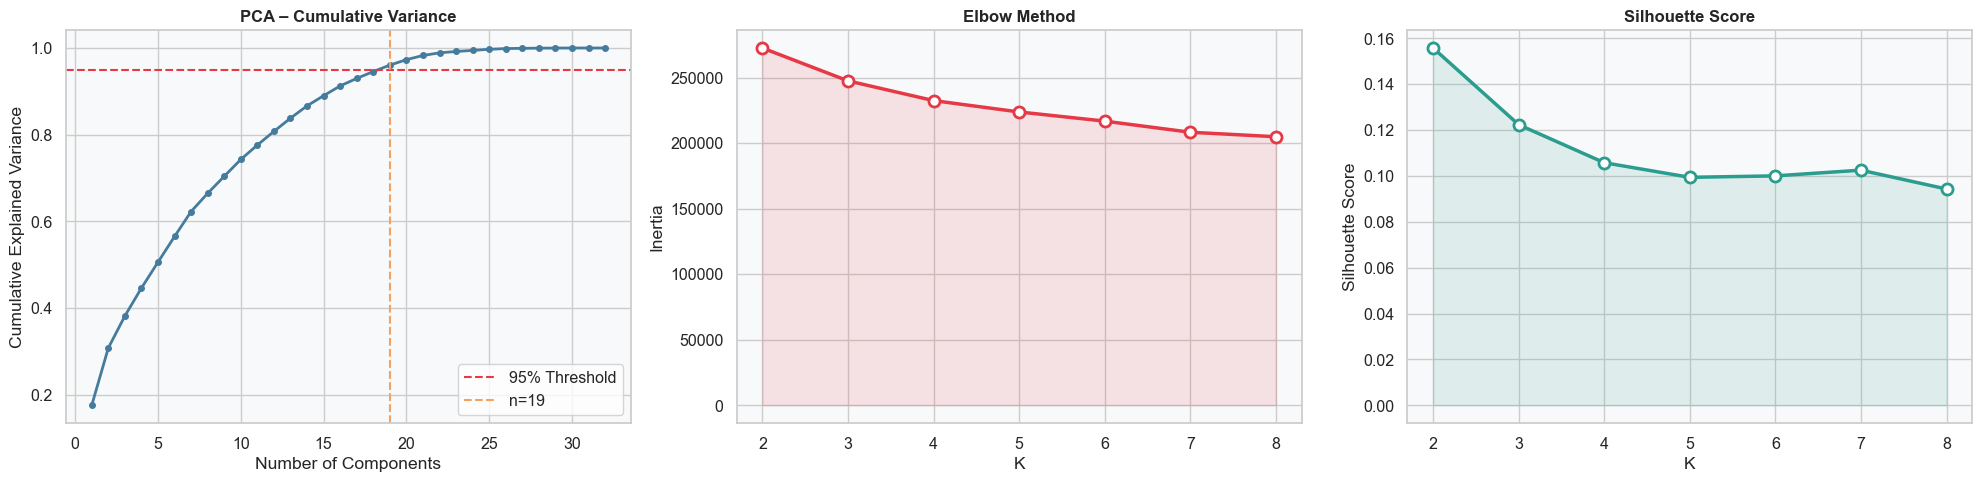


Best K by silhouette: 2 (score=0.1558)


In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

print("="*80)
print("CLUSTERING ANALYSIS")
print("="*80)

# Prepare clustering data: encode categoricals
df_cluster = df.drop(columns=["Attrition_Flag"]).copy()
le_dict = {}
for col in df_cluster.select_dtypes(include=["object","category"]).columns:
    le_dict[col] = LabelEncoder()
    df_cluster[col] = le_dict[col].fit_transform(df_cluster[col].astype(str))

cluster_features = [c for c in df_cluster.columns if c != "Churn"]
X_c = df_cluster[cluster_features].values
scaler_c = StandardScaler()
X_c_scaled = scaler_c.fit_transform(X_c)

# PCA for dimensionality reduction before clustering
pca_full = PCA().fit(X_c_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.95) + 1
print(f"PCA: {n_components} components explain ≥95% variance")

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_c_scaled)

# Plot cumulative explained variance
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(range(1, len(cum_var)+1), cum_var, "o-", color="#457B9D", lw=2, markersize=4)
axes[0].axhline(y=0.95, color="#E63946", linestyle="--", lw=1.5, label="95% Threshold")
axes[0].axvline(x=n_components, color="#F4A261", linestyle="--", lw=1.5, label=f"n={n_components}")
axes[0].set_xlabel("Number of Components"); axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA – Cumulative Variance", fontsize=12, fontweight="bold")
axes[0].legend(); axes[0].set_facecolor("#F8F9FA")

# Elbow + Silhouette on PCA-reduced data
inertia, sil_scores, ch_scores = [], [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels, sample_size=3000, random_state=42))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

axes[1].plot(list(K_range), inertia, "o-", color="#E63946", lw=2.5, markersize=8,
             markerfacecolor="white", markeredgewidth=2)
axes[1].fill_between(list(K_range), inertia, alpha=0.12, color="#E63946")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Inertia")
axes[1].set_title("Elbow Method", fontsize=12, fontweight="bold")
axes[1].set_facecolor("#F8F9FA")

axes[2].plot(list(K_range), sil_scores, "o-", color="#2A9D8F", lw=2.5, markersize=8,
             markerfacecolor="white", markeredgewidth=2)
axes[2].fill_between(list(K_range), sil_scores, alpha=0.12, color="#2A9D8F")
axes[2].set_xlabel("K"); axes[2].set_ylabel("Silhouette Score")
axes[2].set_title("Silhouette Score", fontsize=12, fontweight="bold")
axes[2].set_facecolor("#F8F9FA")

plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"\nBest K by silhouette: {best_k} (score={max(sil_scores):.4f})")

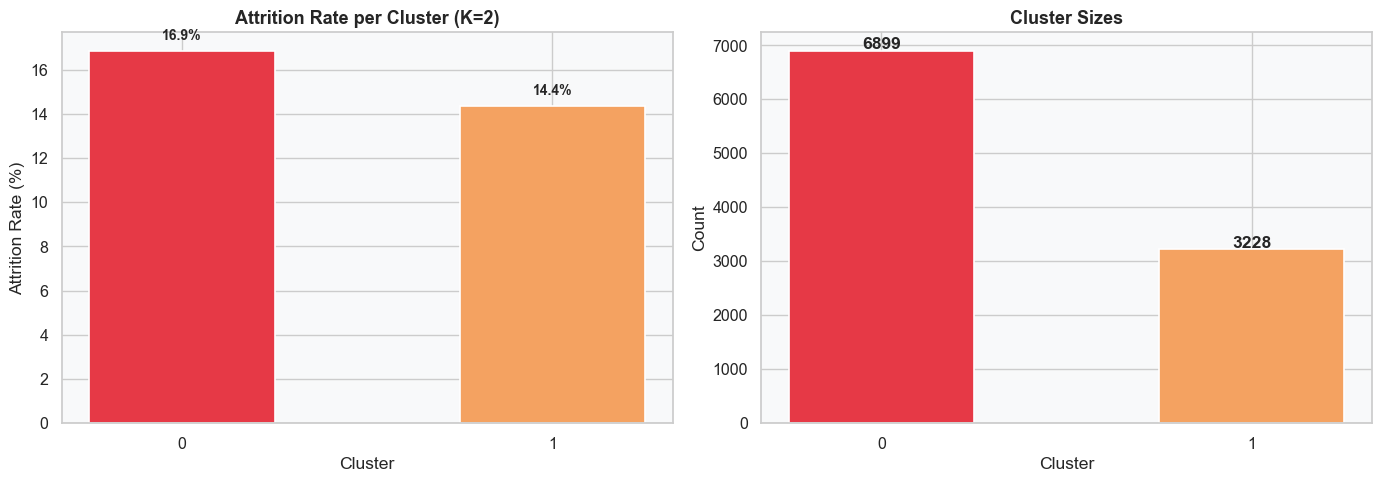


CLUSTER PROFILING (Mean Values):


,Customer_Age,Credit_Limit,Total_Trans_Ct,Total_Trans_Amt,Total_Revolving_Bal,Avg_Utilization_Ratio,Months_Inactive_12_mon,Total_Relationship_Count,EngagementScore,Churn
Cluster,,,,,,,,,,
0,46.506,3994.797,60.101,3377.361,1183.539,0.364,2.364,4.036,240.533,0.169
1,45.942,18542.655,75.028,6598.442,1118.520,0.085,2.292,3.335,234.012,0.144


In [21]:
# ── Final Clustering + Profiling ─────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_pca)
df["Cluster"] = cluster_labels

# Churn rate per cluster
cluster_churn = df.groupby("Cluster")["Churn"].mean().reset_index()
cluster_churn.columns = ["Cluster", "Churn_Rate"]

cluster_colors = PALETTE[:best_k]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate
bars = axes[0].bar(cluster_churn["Cluster"].astype(str), cluster_churn["Churn_Rate"]*100,
                   color=cluster_colors, edgecolor="white", linewidth=1.2, width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Attrition Rate (%)")
axes[0].set_title(f"Attrition Rate per Cluster (K={best_k})", fontsize=13, fontweight="bold")
axes[0].set_facecolor("#F8F9FA")

# Cluster sizes
sizes = df["Cluster"].value_counts().sort_index()
axes[1].bar(sizes.index.astype(str), sizes.values,
            color=cluster_colors, edgecolor="white", linewidth=1.2, width=0.5)
for i, v in enumerate(sizes.values):
    axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Count")
axes[1].set_title("Cluster Sizes", fontsize=13, fontweight="bold")
axes[1].set_facecolor("#F8F9FA")

plt.tight_layout()
plt.show()

# Cluster Profiling: show mean of key features per cluster
profile_cols = ["Customer_Age","Credit_Limit","Total_Trans_Ct","Total_Trans_Amt",
                "Total_Revolving_Bal","Avg_Utilization_Ratio","Months_Inactive_12_mon",
                "Total_Relationship_Count","EngagementScore","Churn"]
cluster_profile = df.groupby("Cluster")[profile_cols].mean().round(3)
print("\nCLUSTER PROFILING (Mean Values):")
print("="*100)
display(cluster_profile.style.background_gradient(cmap="YlOrRd", axis=0)
        .format("{:.3f}"))

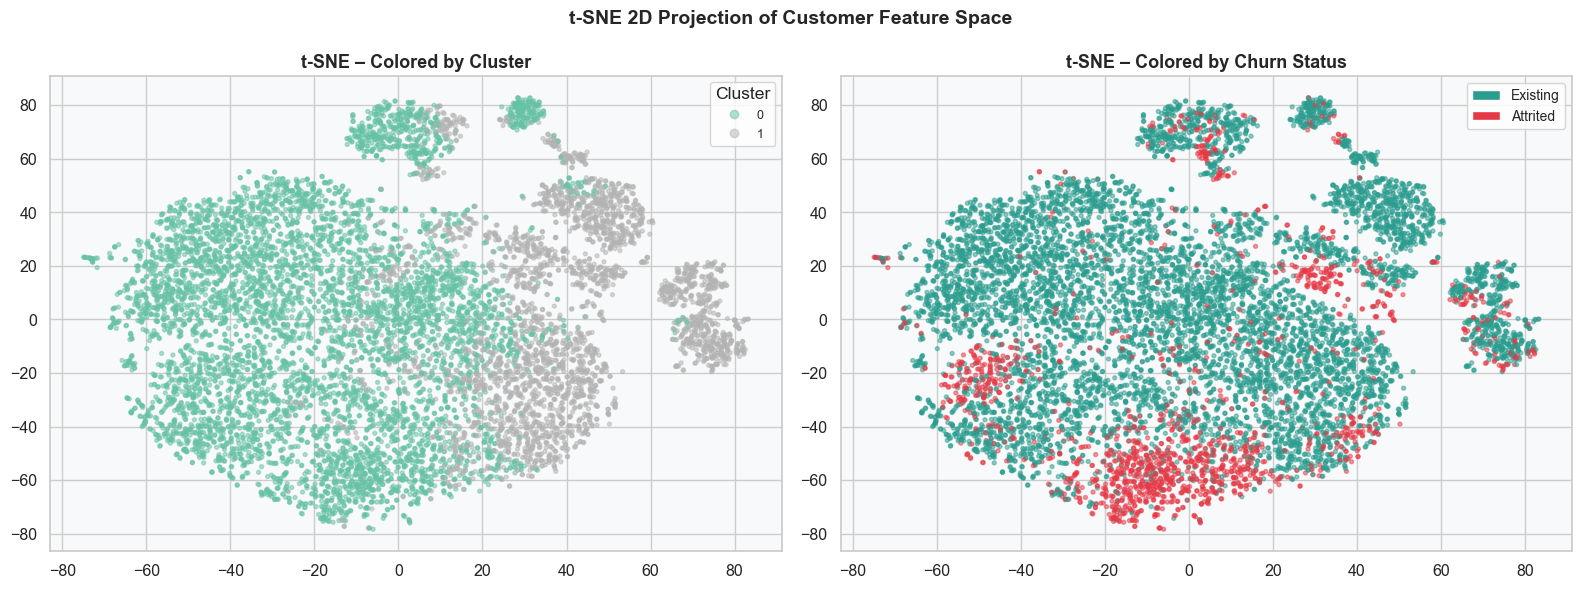

In [22]:
# ── t-SNE Visualization ──────────────────────────────────────
from sklearn.manifold import TSNE

# Use PCA-reduced data for t-SNE (faster and better)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# t-SNE colored by cluster
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=df["Cluster"], cmap="Set2", alpha=0.5, s=8)
axes[0].set_title("t-SNE – Colored by Cluster", fontsize=13, fontweight="bold")
axes[0].legend(*scatter1.legend_elements(), title="Cluster", fontsize=9)
axes[0].set_facecolor("#F8F9FA")

# t-SNE colored by churn
colors_churn = df["Churn"].map({0: "#2A9D8F", 1: "#E63946"})
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors_churn, alpha=0.5, s=8)
legend_elements = [mpatches.Patch(facecolor="#2A9D8F", label="Existing"),
                   mpatches.Patch(facecolor="#E63946", label="Attrited")]
axes[1].legend(handles=legend_elements, fontsize=10)
axes[1].set_title("t-SNE – Colored by Churn Status", fontsize=13, fontweight="bold")
axes[1].set_facecolor("#F8F9FA")

plt.suptitle("t-SNE 2D Projection of Customer Feature Space", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 🔧 Data Preparation

Encoding, train/test split, scaling, and SMOTE oversampling to handle class imbalance.

Features: (10127, 33) | Class distribution: {0: 8500, 1: 1627}
Features count: 33
Train (after SMOTE): (13598, 33) | Test: (2026, 33)


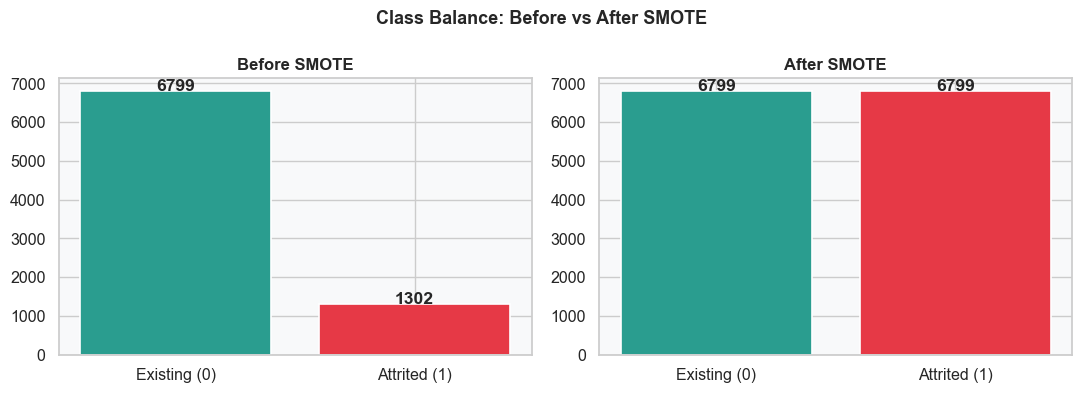

In [23]:
# ── SMOTE & Data Preparation ──────────────────────────────────
from imblearn.over_sampling import SMOTE

df_model = df.drop(columns=["Attrition_Flag"]).copy()
label_encoders = {}
for col in df_model.select_dtypes(include=["object","category"]).columns:
    lenc = LabelEncoder()
    df_model[col] = lenc.fit_transform(df_model[col].astype(str))
    label_encoders[col] = lenc

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"].astype(int)
feature_names = X.columns.tolist()

print(f"Features: {X.shape} | Class distribution: {y.value_counts().to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

n_features = X_train_sm.shape[1]
print(f"Features count: {n_features}")
print(f"Train (after SMOTE): {X_train_sm.shape} | Test: {X_test_scaled.shape}")

# Before / After SMOTE visual
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_sm).value_counts().sort_index()

for ax, data, title in [(axes[0], before, "Before SMOTE"), (axes[1], after, "After SMOTE")]:
    bars = ax.bar(["Existing (0)", "Attrited (1)"], data.values,
                  color=["#2A9D8F", "#E63946"], edgecolor="white", linewidth=1.2)
    for bar, v in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 20, str(v), ha="center", fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_facecolor("#F8F9FA")

plt.suptitle("Class Balance: Before vs After SMOTE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 🤖 Machine Learning Models

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, recall_score

log_reg_model = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42, C=0.5)
log_reg_model.fit(X_train_sm, y_train_sm)
y_pred_lr = log_reg_model.predict(X_test_scaled)
y_prob_lr = log_reg_model.predict_proba(X_test_scaled)[:, 1]
acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy: {acc_lr:.4f} | ROC-AUC: {auc_lr:.4f} | F1: {f1_lr:.4f} | Recall: {rec_lr:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=["Existing","Attrited"]))

LOGISTIC REGRESSION
Accuracy: 0.8746 | ROC-AUC: 0.9305 | F1: 0.6752 | Recall: 0.8123
              precision    recall  f1-score   support

    Existing       0.96      0.89      0.92      1701
    Attrited       0.58      0.81      0.68       325

    accuracy                           0.87      2026
   macro avg       0.77      0.85      0.80      2026
weighted avg       0.90      0.87      0.88      2026



In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion="gini", max_depth=8, min_samples_split=10,
                                  class_weight="balanced", random_state=42)
dt_model.fit(X_train_sm, y_train_sm)
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
acc_dt  = accuracy_score(y_test, y_pred_dt)
auc_dt  = roc_auc_score(y_test, y_prob_dt)
f1_dt   = f1_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
print("="*50)
print("DECISION TREE")
print("="*50)
print(f"Accuracy: {acc_dt:.4f} | ROC-AUC: {auc_dt:.4f} | F1: {f1_dt:.4f} | Recall: {rec_dt:.4f}")
print(classification_report(y_test, y_pred_dt, target_names=["Existing","Attrited"]))

DECISION TREE
Accuracy: 0.9245 | ROC-AUC: 0.9303 | F1: 0.7792 | Recall: 0.8308
              precision    recall  f1-score   support

    Existing       0.97      0.94      0.95      1701
    Attrited       0.73      0.83      0.78       325

    accuracy                           0.92      2026
   macro avg       0.85      0.89      0.87      2026
weighted avg       0.93      0.92      0.93      2026



In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, criterion="gini", max_depth=None,
                                  min_samples_split=5, class_weight="balanced",
                                  n_jobs=-1, random_state=42)
rf_model.fit(X_train_sm, y_train_sm)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
acc_rf  = accuracy_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
print("="*50)
print("RANDOM FOREST")
print("="*50)
print(f"Accuracy: {acc_rf:.4f} | ROC-AUC: {auc_rf:.4f} | F1: {f1_rf:.4f} | Recall: {rec_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=["Existing","Attrited"]))

RANDOM FOREST
Accuracy: 0.9595 | ROC-AUC: 0.9869 | F1: 0.8735 | Recall: 0.8708
              precision    recall  f1-score   support

    Existing       0.98      0.98      0.98      1701
    Attrited       0.88      0.87      0.87       325

    accuracy                           0.96      2026
   macro avg       0.93      0.92      0.92      2026
weighted avg       0.96      0.96      0.96      2026



In [27]:
import xgboost as xgb

neg = int((y_train_sm == 0).sum())
pos = int((y_train_sm == 1).sum())
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=neg/pos,
    eval_metric="logloss", random_state=42, n_jobs=-1
)
xgb_model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_test_scaled, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
auc_xgb  = roc_auc_score(y_test, y_prob_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)
print("="*50)
print("XGBOOST")
print("="*50)
print(f"Accuracy: {acc_xgb:.4f} | ROC-AUC: {auc_xgb:.4f} | F1: {f1_xgb:.4f} | Recall: {rec_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=["Existing","Attrited"]))

XGBOOST
Accuracy: 0.9699 | ROC-AUC: 0.9925 | F1: 0.9039 | Recall: 0.8831
              precision    recall  f1-score   support

    Existing       0.98      0.99      0.98      1701
    Attrited       0.93      0.88      0.90       325

    accuracy                           0.97      2026
   macro avg       0.95      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



In [28]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.03, max_depth=-1,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train_sm, y_train_sm)
y_pred_lgb = lgb_model.predict(X_test_scaled)
y_prob_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]
acc_lgb  = accuracy_score(y_test, y_pred_lgb)
auc_lgb  = roc_auc_score(y_test, y_prob_lgb)
f1_lgb   = f1_score(y_test, y_pred_lgb)
rec_lgb  = recall_score(y_test, y_pred_lgb)
print("="*50)
print("LIGHTGBM")
print("="*50)
print(f"Accuracy: {acc_lgb:.4f} | ROC-AUC: {auc_lgb:.4f} | F1: {f1_lgb:.4f} | Recall: {rec_lgb:.4f}")
print(classification_report(y_test, y_pred_lgb, target_names=["Existing","Attrited"]))

LIGHTGBM
Accuracy: 0.9669 | ROC-AUC: 0.9914 | F1: 0.8945 | Recall: 0.8738
              precision    recall  f1-score   support

    Existing       0.98      0.98      0.98      1701
    Attrited       0.92      0.87      0.89       325

    accuracy                           0.97      2026
   macro avg       0.95      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



# 🧠 Deep Learning Models



In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")

# ── MLP with Skip Connection ────────────────────────────────
def build_mlp(n_features):
    inp = layers.Input(shape=(n_features,))

    # First block
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    # Second block with skip connection
    h = layers.Dense(128, activation="relu")(x)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.3)(h)

    # Third block
    h = layers.Dense(64, activation="relu")(h)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.2)(h)

    # Final
    h = layers.Dense(32, activation="relu")(h)
    out = layers.Dense(1, activation="sigmoid")(h)

    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

mlp_model = build_mlp(n_features)
mlp_model.summary()

callbacks_mlp = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, verbose=1)
]
history_mlp = mlp_model.fit(
    X_train_sm, y_train_sm, validation_split=0.15,
    epochs=150, batch_size=256, callbacks=callbacks_mlp, verbose=1
)

TensorFlow: 2.20.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,761 (210.00 KB)

 Trainable params: 52,865 (206.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7795 - loss: 0.4617 - val_accuracy: 0.8608 - val_loss: 0.4253 - learning_rate: 0.0010
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8776 - loss: 0.2849 - val_accuracy: 0.8794 - val_loss: 0.3685 - learning_rate: 0.0010
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8922 - loss: 0.2502 - val_accuracy: 0.9044 - val_loss: 0.3105 - learning_rate: 0.0010
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9028 - loss: 0.2291 - val_accuracy: 0.9260 - val_loss: 0.2509 - learning_rate: 0.0010
Epoch 5/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9121 - loss: 0.2097 - val_accuracy: 0.9368 - val_loss: 0.2135 - learning_rate: 0.0010
Epoch 6/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9198 - loss: 0.1955 - val_accuracy: 0.9431 - val_loss: 0.1916 - learning_rate: 0.0010
Epoch 7/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9277 - loss: 0.1831 - val_acc

In [30]:
mlp_prob = mlp_model.predict(X_test_scaled).flatten()
mlp_pred = (mlp_prob > 0.5).astype(int)
acc_mlp  = accuracy_score(y_test, mlp_pred)
auc_mlp  = roc_auc_score(y_test, mlp_prob)
f1_mlp   = f1_score(y_test, mlp_pred)
rec_mlp  = recall_score(y_test, mlp_pred)
print(f"MLP -> Accuracy: {acc_mlp:.4f} | ROC-AUC: {auc_mlp:.4f} | F1: {f1_mlp:.4f} | Recall: {rec_mlp:.4f}")
print(classification_report(y_test, mlp_pred, target_names=["Existing","Attrited"]))

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MLP -> Accuracy: 0.9571 | ROC-AUC: 0.9821 | F1: 0.8647 | Recall: 0.8554
              precision    recall  f1-score   support

    Existing       0.97      0.98      0.97      1701
    Attrited       0.87      0.86      0.86       325

    accuracy                           0.96      2026
   macro avg       0.92      0.92      0.92      2026
weighted avg       0.96      0.96      0.96      2026



In [31]:
# ── 1D CNN with Residual Block ───────────────────────────────
X_train_3d = X_train_sm.reshape(X_train_sm.shape[0], n_features, 1)
X_test_3d  = X_test_scaled.reshape(X_test_scaled.shape[0], n_features, 1)

def build_cnn(n_features):
    inp = layers.Input(shape=(n_features, 1))

    # Block 1
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)

    # Block 2 with residual
    h = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    h = layers.BatchNormalization()(h)
    x = layers.Add()([x, h])  # Residual connection
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)

    # Block 3
    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Multi-scale pooling: combine global avg + global max
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

cnn = build_cnn(n_features)
cnn.summary()

callbacks_cnn = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, verbose=1)
]
history_cnn = cnn.fit(
    X_train_3d, y_train_sm, validation_split=0.15,
    epochs=100, batch_size=256, callbacks=callbacks_cnn, verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 33, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 33, 64)    │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 33, 64)    │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 33, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 33, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 16, 64)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 16, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,897 (222.25 KB)

 Trainable params: 56,385 (220.25 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7525 - loss: 0.5169 - val_accuracy: 0.4627 - val_loss: 0.7152 - learning_rate: 0.0010
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8792 - loss: 0.2955 - val_accuracy: 0.6882 - val_loss: 0.6592 - learning_rate: 0.0010
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9076 - loss: 0.2262 - val_accuracy: 0.8020 - val_loss: 0.5951 - learning_rate: 0.0010
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9354 - loss: 0.1718 - val_accuracy: 0.8544 - val_loss: 0.5403 - learning_rate: 0.0010
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9431 - loss: 0.1543 - val_accuracy: 0.7750 - val_loss: 0.5698 - learning_rate: 0.0010
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9514 - loss: 0.1281 - val_accuracy: 0.8098 - val_loss: 0.4851 - learning_rate: 0.0010
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9625 - loss: 0.1034 - 

In [32]:
cnn_prob = cnn.predict(X_test_3d).flatten()
cnn_pred = (cnn_prob > 0.5).astype(int)
acc_cnn  = accuracy_score(y_test, cnn_pred)
auc_cnn  = roc_auc_score(y_test, cnn_prob)
f1_cnn   = f1_score(y_test, cnn_pred)
rec_cnn  = recall_score(y_test, cnn_pred)
print(f"CNN -> Accuracy: {acc_cnn:.4f} | ROC-AUC: {auc_cnn:.4f} | F1: {f1_cnn:.4f} | Recall: {rec_cnn:.4f}")
print(classification_report(y_test, cnn_pred, target_names=["Existing","Attrited"]))

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CNN -> Accuracy: 0.9176 | ROC-AUC: 0.9649 | F1: 0.7782 | Recall: 0.9015
              precision    recall  f1-score   support

    Existing       0.98      0.92      0.95      1701
    Attrited       0.68      0.90      0.78       325

    accuracy                           0.92      2026
   macro avg       0.83      0.91      0.86      2026
weighted avg       0.93      0.92      0.92      2026



In [33]:
# ══════════════════════════════════════════════════════════════
# TRANSFORMER
# ══════════════════════════════════════════════════════════════


class TransformerBlock(layers.Layer):
    # Pre-norm Transformer block with proper residual connections.
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout_rate),
            layers.Dense(d_model),
            layers.Dropout(dropout_rate),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        # Pre-norm: normalize → attention → residual
        x_norm = self.norm1(x)
        attn_out = self.att(x_norm, x_norm, training=training)
        attn_out = self.dropout(attn_out, training=training)
        x = x + attn_out

        # Pre-norm: normalize → FFN → residual
        x_norm = self.norm2(x)
        ffn_out = self.ffn(x_norm, training=training)
        x = x + ffn_out
        return x


def build_transformer(n_features, d_model=64, num_heads=4, ff_dim=128, num_blocks=2, dropout=0.1):
    inp = layers.Input(shape=(n_features,))

    # Reshape: (batch, n_features) → (batch, n_features, 1)
    x = layers.Reshape((n_features, 1))(inp)

    # Project each feature to d_model dimensions
    # This is the KEY fix: gives attention enough information per token
    x = layers.Dense(d_model)(x)  # (batch, n_features, d_model)

    # Learned positional encoding
    positions = tf.range(start=0, limit=n_features, delta=1)
    pos_emb_layer = layers.Embedding(input_dim=n_features, output_dim=d_model)
    x = x + pos_emb_layer(positions)  # Broadcast over batch

    x = layers.Dropout(dropout)(x)

    # Stacked Transformer blocks
    for i in range(num_blocks):
        x = TransformerBlock(d_model, num_heads, ff_dim, dropout, name=f"transformer_block_{i}")(x)

    # Final layer norm
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Classification head: global average pooling + MLP
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="gelu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="gelu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(5e-4),  # Lower LR for transformers
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

transformer = build_transformer(n_features)
transformer.summary()

callbacks_tr = [
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6, verbose=1)
]

# Note: Transformer takes 2D input (batch, n_features), NOT 3D
# The Reshape layer inside the model handles the conversion
tr_history = transformer.fit(
    X_train_sm, y_train_sm, validation_split=0.15,
    epochs=150, batch_size=256, callbacks=callbacks_tr, verbose=1
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 33, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 33, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 33, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 33, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 33, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,473 (287.00 KB)

 Trainable params: 73,473 (287.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.6884 - loss: 0.5964 - val_accuracy: 0.6529 - val_loss: 0.5880 - learning_rate: 5.0000e-04
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.7561 - loss: 0.4981 - val_accuracy: 0.7074 - val_loss: 0.5815 - learning_rate: 5.0000e-04
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.7866 - loss: 0.4378 - val_accuracy: 0.9074 - val_loss: 0.3084 - learning_rate: 5.0000e-04
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.8027 - loss: 0.4175 - val_accuracy: 0.9275 - val_loss: 0.2659 - learning_rate: 5.0000e-04
Epoch 5/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.8065 - loss: 0.4058 - val_accuracy: 0.8946 - val_loss: 0.2776 - learning_rate: 5.0000e-04
Epoch 6/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.8311 - loss: 0.3719 - val_accuracy: 0.8824 - val_loss: 0.2650 - learning_rate: 5.0000e-04
Epoch 7/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - ac

In [34]:
tr_prob = transformer.predict(X_test_scaled).flatten()
tr_pred = (tr_prob > 0.5).astype(int)
acc_tr  = accuracy_score(y_test, tr_pred)
auc_tr  = roc_auc_score(y_test, tr_prob)
f1_tr   = f1_score(y_test, tr_pred)
rec_tr  = recall_score(y_test, tr_pred)
print(f"Transformer -> Accuracy: {acc_tr:.4f} | ROC-AUC: {auc_tr:.4f} | F1: {f1_tr:.4f} | Recall: {rec_tr:.4f}")
print(classification_report(y_test, tr_pred, target_names=["Existing","Attrited"]))

if auc_tr < 0.7:
    print("\n⚠️  Transformer AUC is still low. This can happen due to:")
    print("  - Small tabular dataset (transformers need more data)")
    print("  - Random seed effects on attention initialization")
    print("  - Tabular data is NOT the ideal domain for transformers")
    print("  - Tree-based models (XGBoost, LightGBM) are the SOTA for tabular data")

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Transformer -> Accuracy: 0.9319 | ROC-AUC: 0.9665 | F1: 0.7909 | Recall: 0.8031
              precision    recall  f1-score   support

    Existing       0.96      0.96      0.96      1701
    Attrited       0.78      0.80      0.79       325

    accuracy                           0.93      2026
   macro avg       0.87      0.88      0.88      2026
weighted avg       0.93      0.93      0.93      2026



# 📊 Model Comparison & Evaluation

In [35]:
# ── Model Comparison Table ────────────────────────────────────
comparison = pd.DataFrame({
    "Model":    ["Logistic Regression","Decision Tree","Random Forest",
                 "XGBoost","LightGBM","MLP","1D CNN","Transformer"],
    "Accuracy": [acc_lr, acc_dt, acc_rf, acc_xgb, acc_lgb, acc_mlp, acc_cnn, acc_tr],
    "ROC-AUC":  [auc_lr, auc_dt, auc_rf, auc_xgb, auc_lgb, auc_mlp, auc_cnn, auc_tr],
    "F1-Score": [f1_lr, f1_dt, f1_rf, f1_xgb, f1_lgb, f1_mlp, f1_cnn, f1_tr],
    "Recall":   [rec_lr, rec_dt, rec_rf, rec_xgb, rec_lgb, rec_mlp, rec_cnn, rec_tr]
})
comparison.sort_values("ROC-AUC", ascending=False, inplace=True)
comparison.reset_index(drop=True, inplace=True)

print("MODEL PERFORMANCE COMPARISON")
print("="*80)
display(comparison.style
        .format("{:.4f}", subset=["Accuracy","ROC-AUC","F1-Score","Recall"])
        .background_gradient(cmap="RdYlGn", subset=["Accuracy","ROC-AUC","F1-Score","Recall"])
        .highlight_max(subset=["Accuracy","ROC-AUC","F1-Score","Recall"],
                       color="#90EE90", props="font-weight:bold;")
        .set_caption("Model Comparison (Sorted by ROC-AUC)"))

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,ROC-AUC,F1-Score,Recall
0,XGBoost,0.9699,0.9925,0.9039,0.8831
1,LightGBM,0.9669,0.9914,0.8945,0.8738
2,Random Forest,0.9595,0.9869,0.8735,0.8708
3,MLP,0.9571,0.9821,0.8647,0.8554
4,Transformer,0.9319,0.9665,0.7909,0.8031
5,1D CNN,0.9176,0.9649,0.7782,0.9015
6,Logistic Regression,0.8746,0.9305,0.6752,0.8123
7,Decision Tree,0.9245,0.9303,0.7792,0.8308


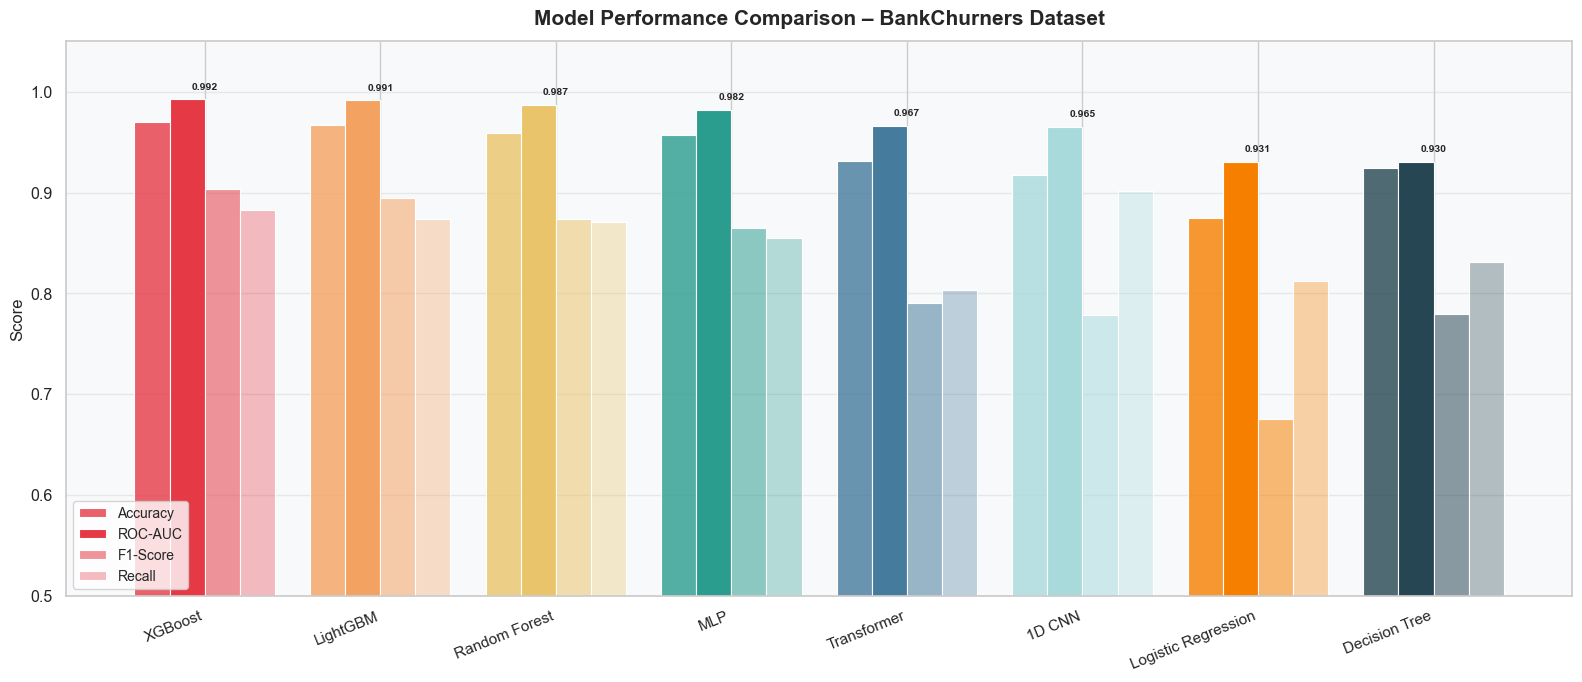

In [36]:
# ── Performance Bar Chart ─────────────────────────────────────
model_colors = ["#E63946","#F4A261","#E9C46A","#2A9D8F","#457B9D","#A8DADC","#F77F00","#264653"]
x = np.arange(len(comparison))
w = 0.2

fig, ax = plt.subplots(figsize=(16, 7))
metrics = ["Accuracy", "ROC-AUC", "F1-Score", "Recall"]
for j, metric in enumerate(metrics):
    bars = ax.bar(x + (j - 1.5) * w, comparison[metric], w, label=metric,
                  color=[c + ["CC","FF","88","55"][j] for c in model_colors[:len(comparison)]],
                  edgecolor="white", linewidth=0.8)

# Add ROC-AUC values on top
for i, (_, row) in enumerate(comparison.iterrows()):
    ax.text(i, row["ROC-AUC"] + 0.008, f'{row["ROC-AUC"]:.3f}',
            ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=22, ha="right", fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison – BankChurners Dataset",
             fontsize=15, fontweight="bold", pad=12)
ax.legend(fontsize=10, loc="lower left")
ax.set_facecolor("#F8F9FA")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

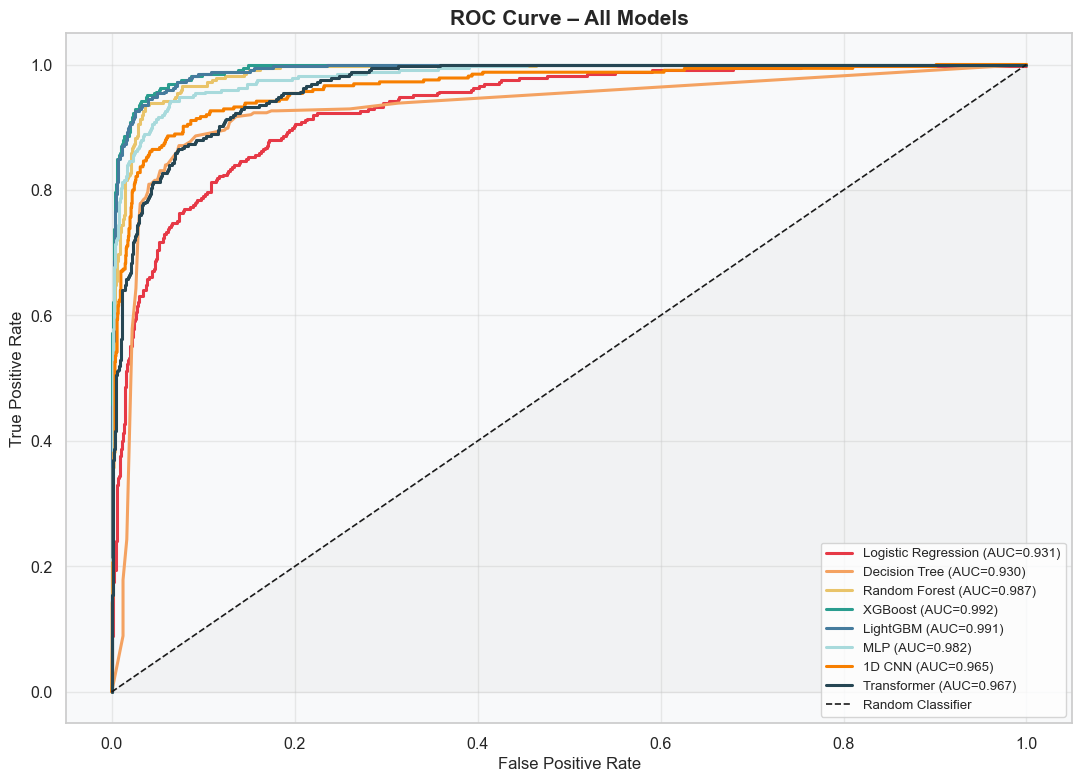

In [37]:
# ── ROC Curve Comparison ──────────────────────────────────────
from sklearn.metrics import roc_curve, auc as roc_auc_fn

model_probs = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree":       y_prob_dt,
    "Random Forest":       y_prob_rf,
    "XGBoost":             y_prob_xgb,
    "LightGBM":            y_prob_lgb,
    "MLP":                 mlp_prob,
    "1D CNN":              cnn_prob,
    "Transformer":         tr_prob
}
roc_colors = ["#E63946","#F4A261","#E9C46A","#2A9D8F","#457B9D","#A8DADC","#F77F00","#264653"]

plt.figure(figsize=(11, 8))
for (name, prob), color in zip(model_probs.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    rval = roc_auc_fn(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={rval:.3f})", color=color, lw=2.2)

plt.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
plt.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve – All Models", fontsize=15, fontweight="bold")
plt.legend(loc="lower right", fontsize=9.5)
plt.gca().set_facecolor("#F8F9FA")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

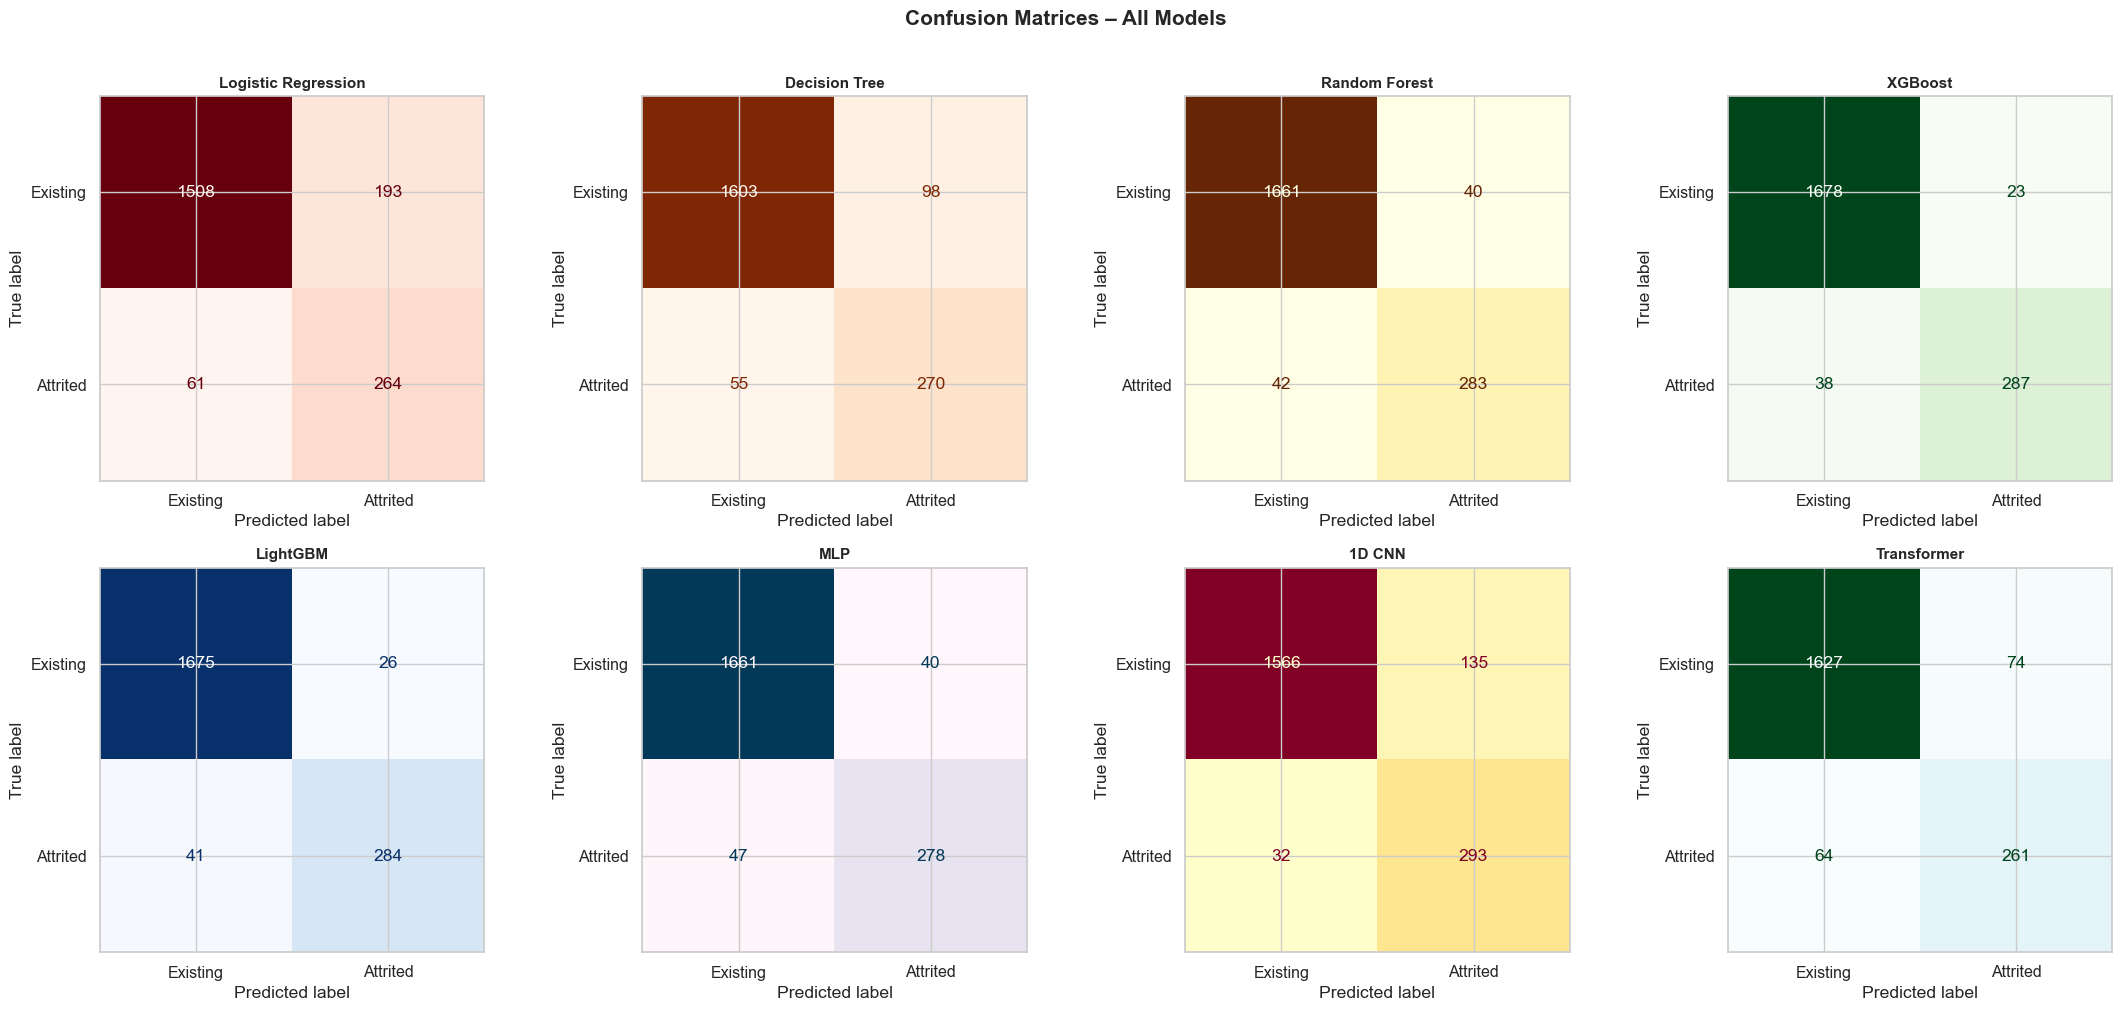

In [38]:
# ── Confusion Matrices ───────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_preds = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree":       y_pred_dt,
    "Random Forest":       y_pred_rf,
    "XGBoost":             y_pred_xgb,
    "LightGBM":            y_pred_lgb,
    "MLP":                 mlp_pred,
    "1D CNN":              cnn_pred,
    "Transformer":         tr_pred
}
cm_cmaps = ["Reds","Oranges","YlOrBr","Greens","Blues","PuBu","YlOrRd","BuGn"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()
for ax, (name, pred), cmap in zip(axes, model_preds.items(), cm_cmaps):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Existing","Attrited"])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=11, fontweight="bold")

plt.suptitle("Confusion Matrices – All Models", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

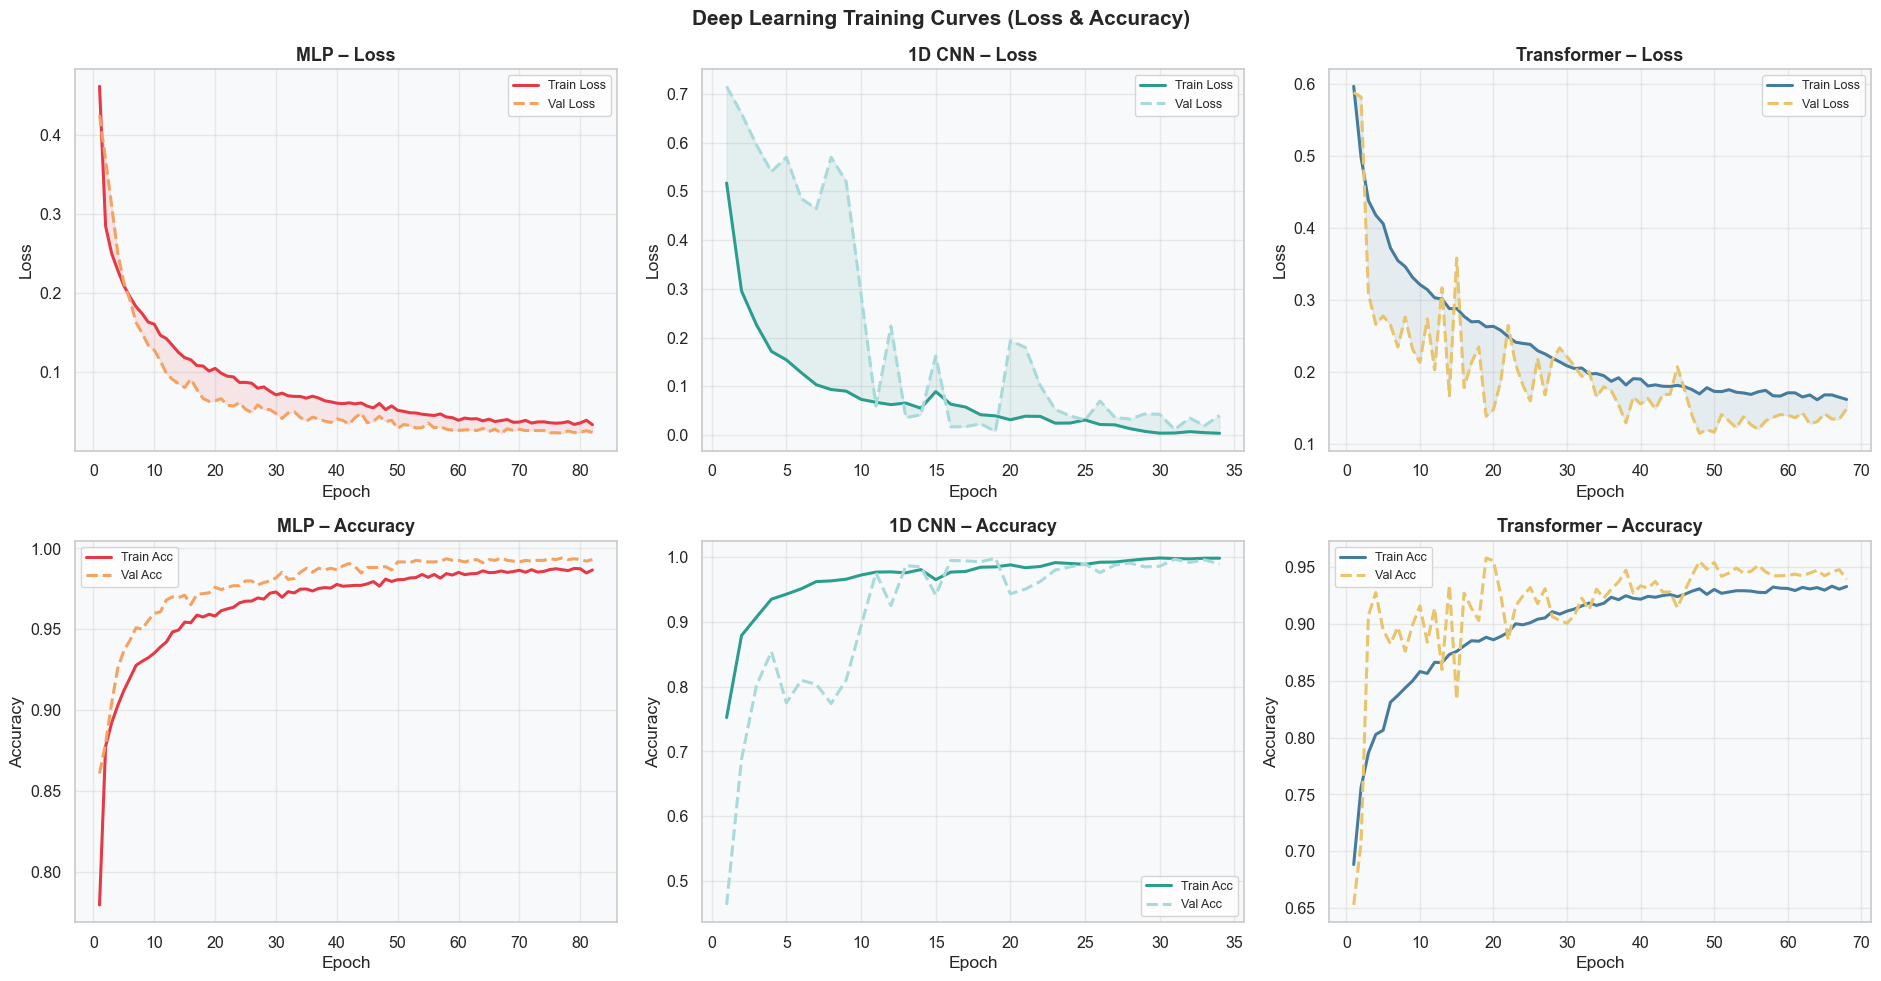

In [39]:
# ── Deep Learning Training Curves ─────────────────────────────
dl_colors = [
    ("#E63946","#F4A261"),
    ("#2A9D8F","#A8DADC"),
    ("#457B9D","#E9C46A"),
]

fig, axes = plt.subplots(2, 3, figsize=(19, 10))

for col_idx, (history, name, (tc, vc)) in enumerate(zip(
        [history_mlp, history_cnn, tr_history],
        ["MLP","1D CNN","Transformer"],
        dl_colors)):
    # Loss curves (top row)
    ax = axes[0, col_idx]
    epochs = range(1, len(history.history["loss"]) + 1)
    ax.plot(epochs, history.history["loss"], color=tc, lw=2.2, label="Train Loss")
    ax.plot(epochs, history.history["val_loss"], color=vc, lw=2.2, linestyle="--", label="Val Loss")
    ax.fill_between(epochs, history.history["loss"], history.history["val_loss"], alpha=0.10, color=tc)
    ax.set_title(f"{name} – Loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=9); ax.set_facecolor("#F8F9FA"); ax.grid(alpha=0.4)

    # Accuracy curves (bottom row)
    ax2 = axes[1, col_idx]
    ax2.plot(epochs, history.history["accuracy"], color=tc, lw=2.2, label="Train Acc")
    ax2.plot(epochs, history.history["val_accuracy"], color=vc, lw=2.2, linestyle="--", label="Val Acc")
    ax2.set_title(f"{name} – Accuracy", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(fontsize=9); ax2.set_facecolor("#F8F9FA"); ax2.grid(alpha=0.4)

plt.suptitle("Deep Learning Training Curves (Loss & Accuracy)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# 🔍 SHAP Feature Importance – XGBoost

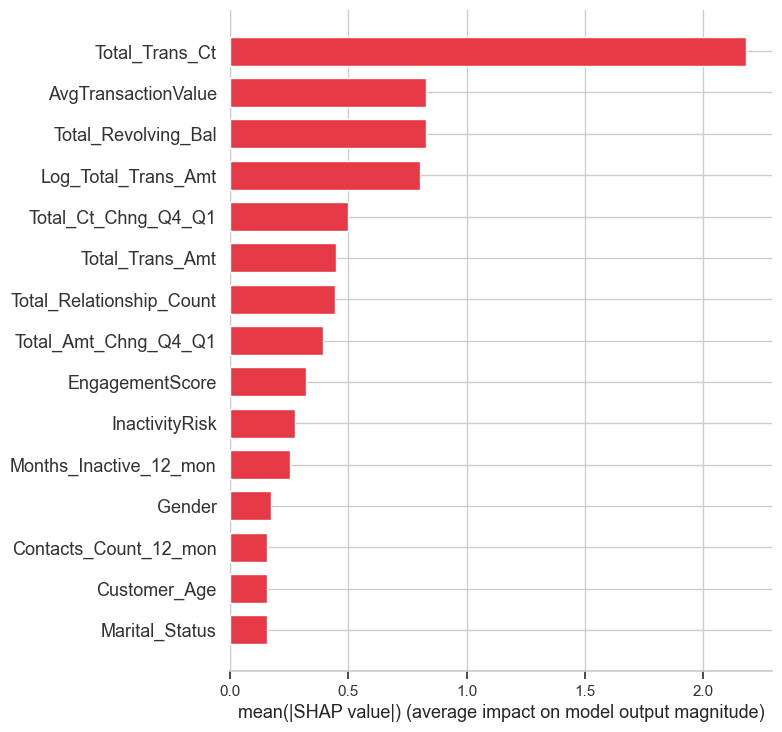

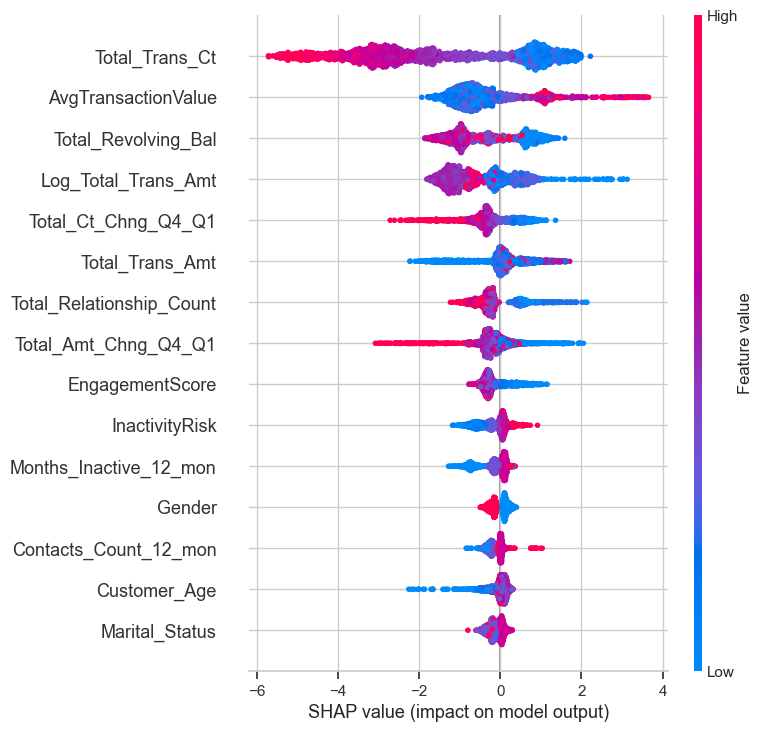

In [40]:
import shap

X_train_df = pd.DataFrame(X_train_sm, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled, columns=feature_names)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

# Bar plot (global importance)
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=15, color="#E63946")

# Beeswarm plot (direction of effect)
shap.summary_plot(shap_values, X_test_df, max_display=15)

# 🌟 Feature Importance Plots

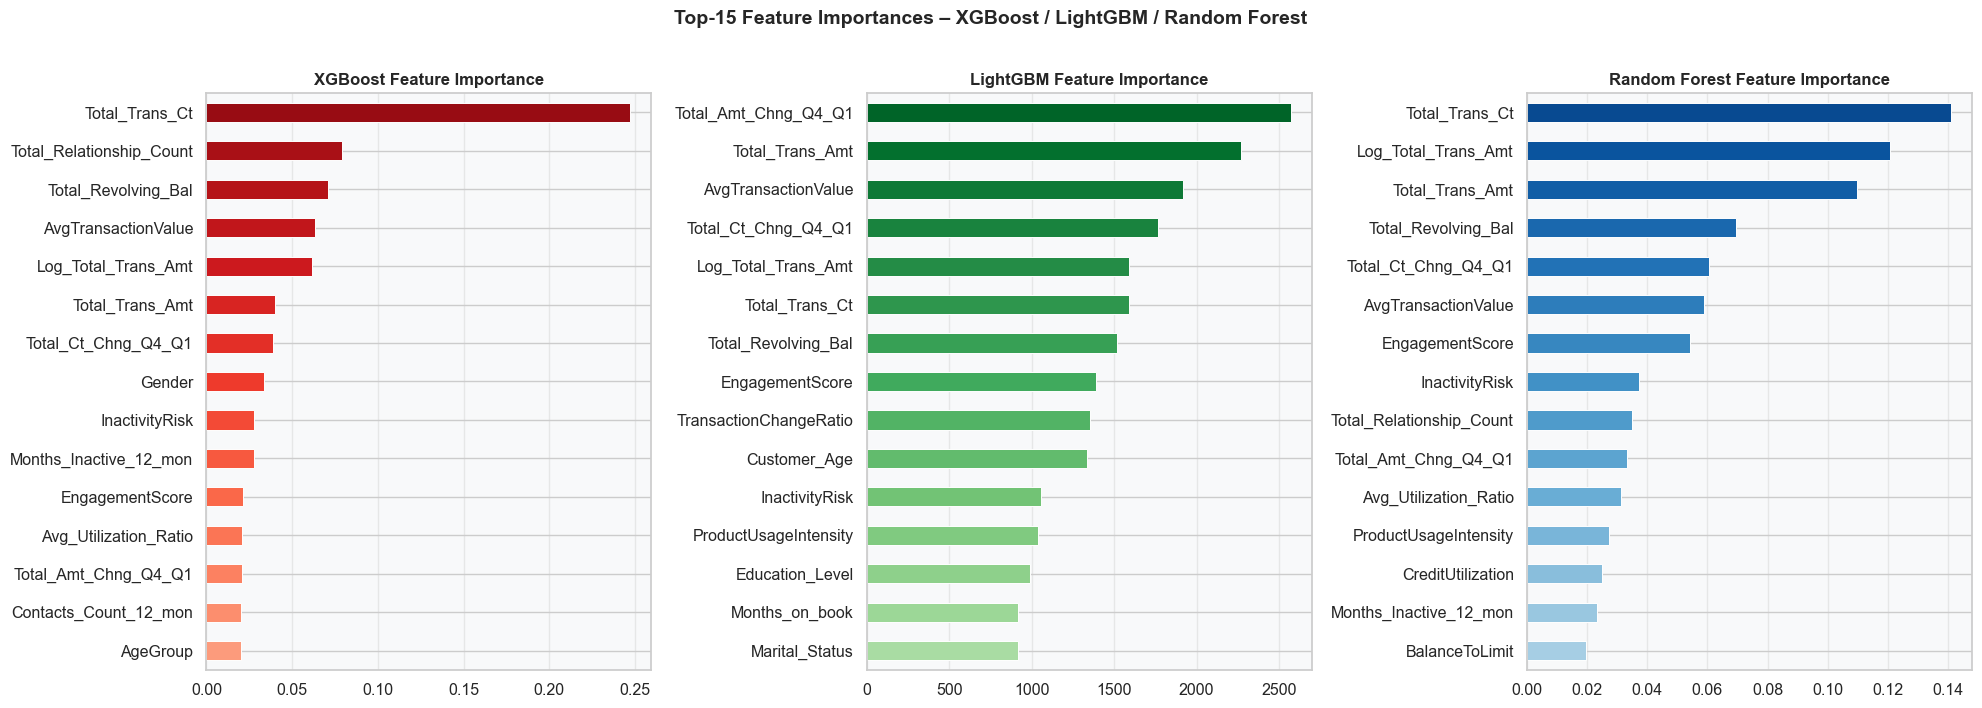

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# XGBoost
feat_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names)
feat_xgb = feat_xgb.sort_values(ascending=True).tail(15)
colors_xgb = plt.cm.Reds(np.linspace(0.35, 0.9, len(feat_xgb)))
feat_xgb.plot(kind="barh", ax=axes[0], color=colors_xgb, edgecolor="white", linewidth=0.7)
axes[0].set_title("XGBoost Feature Importance", fontsize=12, fontweight="bold")
axes[0].set_facecolor("#F8F9FA"); axes[0].grid(axis="x", alpha=0.4)

# LightGBM
feat_lgb = pd.Series(lgb_model.feature_importances_, index=feature_names)
feat_lgb = feat_lgb.sort_values(ascending=True).tail(15)
colors_lgb = plt.cm.Greens(np.linspace(0.35, 0.9, len(feat_lgb)))
feat_lgb.plot(kind="barh", ax=axes[1], color=colors_lgb, edgecolor="white", linewidth=0.7)
axes[1].set_title("LightGBM Feature Importance", fontsize=12, fontweight="bold")
axes[1].set_facecolor("#F8F9FA"); axes[1].grid(axis="x", alpha=0.4)

# Random Forest
feat_rf = pd.Series(rf_model.feature_importances_, index=feature_names)
feat_rf = feat_rf.sort_values(ascending=True).tail(15)
colors_rf = plt.cm.Blues(np.linspace(0.35, 0.9, len(feat_rf)))
feat_rf.plot(kind="barh", ax=axes[2], color=colors_rf, edgecolor="white", linewidth=0.7)
axes[2].set_title("Random Forest Feature Importance", fontsize=12, fontweight="bold")
axes[2].set_facecolor("#F8F9FA"); axes[2].grid(axis="x", alpha=0.4)

plt.suptitle("Top-15 Feature Importances – XGBoost / LightGBM / Random Forest",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 🧩 LIME Explainability – XGBoost

LIME explanation for test sample #17 (True: Attrited, Predicted: Attrited)


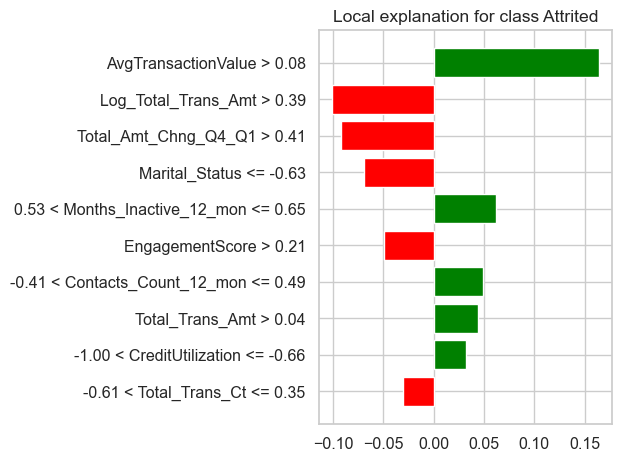

In [42]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_sm,
    feature_names=feature_names,
    class_names=["Existing","Attrited"],
    mode="classification"
)

# Explain a correctly predicted attrited customer
attrited_indices = np.where(y_test.values == 1)[0]
for idx in attrited_indices[:5]:
    if y_pred_xgb[idx] == 1:  # correctly predicted
        break

exp = lime_explainer.explain_instance(
    X_test_scaled[idx], xgb_model.predict_proba, num_features=10
)
print(f"LIME explanation for test sample #{idx} (True: Attrited, Predicted: {'Attrited' if y_pred_xgb[idx]==1 else 'Existing'})")
exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════

best = comparison.iloc[0]

print("="*60)
print("BEST PERFORMING MODEL")
print("="*60)
print(f"Model     : {best['Model']}")
print(f"Accuracy  : {best['Accuracy']:.4f}")
print(f"ROC-AUC   : {best['ROC-AUC']:.4f}")
print(f"F1-Score  : {best['F1-Score']:.4f}")
print(f"Recall    : {best['Recall']:.4f}")s
print("="*60)

display(comparison.style
        .format("{:.4f}", subset=["Accuracy","ROC-AUC","F1-Score","Recall"])
        .background_gradient(cmap="RdYlGn", subset=["Accuracy","ROC-AUC","F1-Score","Recall"])
        .highlight_max(subset=["Accuracy","ROC-AUC","F1-Score","Recall"],
                       color="#90EE90", props="font-weight:bold;")
        .set_caption("Final Model Comparison (Sorted by ROC-AUC)"))



BEST PERFORMING MODEL
Model     : XGBoost
Accuracy  : 0.9699
ROC-AUC   : 0.9925
F1-Score  : 0.9039
Recall    : 0.8831


,Model,Accuracy,ROC-AUC,F1-Score,Recall
0,XGBoost,0.9699,0.9925,0.9039,0.8831
1,LightGBM,0.9669,0.9914,0.8945,0.8738
2,Random Forest,0.9595,0.9869,0.8735,0.8708
3,MLP,0.9571,0.9821,0.8647,0.8554
4,Transformer,0.9319,0.9665,0.7909,0.8031
5,1D CNN,0.9176,0.9649,0.7782,0.9015
6,Logistic Regression,0.8746,0.9305,0.6752,0.8123
7,Decision Tree,0.9245,0.9303,0.7792,0.8308
